In [1]:
# === Conexion Athena estilo Cruce + fallback awswrangler ===
import os
import re
import sys
from pathlib import Path

import boto3
import awswrangler as wr
import pandas as pd

EXPLICIT_CREDENTIALS_SH = Path(r"c:/Users/b46637/OneDrive - Interbank/conexion_aws/athena_conection_test/credentials.sh")


def _find_dir_with_athena_client(preferred_dir: Path | None = None) -> Path | None:
    cwd = Path.cwd().resolve()
    search_roots = []

    if preferred_dir is not None:
        search_roots.append(preferred_dir)

    search_roots.extend([cwd, *cwd.parents])

    home = Path.home()
    search_roots.extend([
        home / "OneDrive - Interbank" / "conexion_aws" / "athena_conection_test",
        Path("c:/Users/b46637/OneDrive - Interbank/conexion_aws/athena_conection_test"),
    ])

    visited = set()
    for root in search_roots:
        if root in visited:
            continue
        visited.add(root)

        if not root.exists():
            continue
        if (root / "athena_client.py").exists() and (root / "athena_config.json").exists():
            return root
    return None


def _load_credentials_from_sh(sh_path: Path) -> list[str]:
    if not sh_path.exists():
        return []

    loaded_keys: list[str] = []
    pattern = re.compile(r'^\s*export\s+([A-Za-z_][A-Za-z0-9_]*)=(.*)$')

    for line in sh_path.read_text(encoding="utf-8", errors="ignore").splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        match = pattern.match(line)
        if not match:
            continue

        key, raw_val = match.groups()
        value = raw_val.strip().strip('"').strip("'")
        if key and value:
            os.environ[key] = value
            loaded_keys.append(key)

    return loaded_keys


def _build_session(aws_region: str) -> boto3.Session:
    aws_profile = os.getenv("AWS_PROFILE")
    if aws_profile:
        return boto3.Session(profile_name=aws_profile, region_name=aws_region)
    return boto3.Session(region_name=aws_region)


def _session_is_valid(sess: boto3.Session) -> tuple[bool, str | None]:
    try:
        sts = sess.client("sts")
        _ = sts.get_caller_identity()
        return True, None
    except Exception as exc:
        return False, str(exc)


ATHENA_MODE = "wrangler"
ATHENA_DATABASE = os.getenv("ATHENA_DATABASE", "disc_comercial")
ATHENA_WORKGROUP = os.getenv("ATHENA_WORKGROUP", "primary")
ATHENA_OUTPUT = os.getenv(
    "ATHENA_OUTPUT",
    "s3://ibk-discovery-comercial-us-east-1-654654352211-data/discovery/comercial/sanherna/athena_results/"
 )
AWS_REGION = os.getenv("AWS_REGION", "us-east-1")

client = None

credentials_file = EXPLICIT_CREDENTIALS_SH if EXPLICIT_CREDENTIALS_SH.exists() else None
if credentials_file is None:
    print(f"⚠ No se encontró credentials.sh en ruta fija: {EXPLICIT_CREDENTIALS_SH}")

preferred_dir = credentials_file.parent if credentials_file is not None else None
athena_dir = _find_dir_with_athena_client(preferred_dir=preferred_dir)
loaded_cred_keys: list[str] = []

if credentials_file is not None:
    loaded_cred_keys = _load_credentials_from_sh(credentials_file)
    if loaded_cred_keys:
        print(f"✓ Credenciales cargadas desde: {credentials_file}")
elif athena_dir is not None:
    fallback_sh = athena_dir / "credentials.sh"
    loaded_cred_keys = _load_credentials_from_sh(fallback_sh)
    if loaded_cred_keys:
        print(f"✓ Credenciales cargadas desde: {fallback_sh}")

try:
    session = _build_session(AWS_REGION)
except Exception:
    session = boto3.Session(region_name=AWS_REGION)

ok_session, session_error = _session_is_valid(session)
if not ok_session and session_error and "ExpiredToken" in session_error and loaded_cred_keys:
    print("⚠ Se detectó token expirado en credentials.sh. Reintentando con credenciales locales (perfil/default)...")
    for key in ["AWS_ACCESS_KEY_ID", "AWS_SECRET_ACCESS_KEY", "AWS_SESSION_TOKEN"]:
        os.environ.pop(key, None)
    session = _build_session(AWS_REGION)

if athena_dir is not None:
    if str(athena_dir) not in sys.path:
        sys.path.append(str(athena_dir))
    try:
        from athena_client import AthenaClient

        if credentials_file is None:
            credentials_file = athena_dir / "credentials.sh"

        client = AthenaClient(
            credentials_file=str(credentials_file),
            config_file=str(athena_dir / "athena_config.json"),
        )
        ATHENA_MODE = "athena_client"
        print(f"✓ AthenaClient cargado desde: {athena_dir}")
    except Exception as exc:
        print(f"⚠ No se pudo inicializar AthenaClient ({exc}). Se usará awswrangler.")
else:
    print("⚠ No se encontró athena_client.py + athena_config.json. Se usará awswrangler.")


def athena_query(query: str, database: str = ATHENA_DATABASE) -> pd.DataFrame:
    if ATHENA_MODE == "athena_client" and client is not None:
        return client.query(query)
    return wr.athena.read_sql_query(
        sql=query,
        database=database,
        ctas_approach=False,
        boto3_session=session,
        workgroup=ATHENA_WORKGROUP,
        s3_output=ATHENA_OUTPUT,
    )


def s3_read_csv(path: str, sep: str = "|", **kwargs) -> pd.DataFrame:
    return wr.s3.read_csv(path=path, sep=sep, boto3_session=session, **kwargs)


def test_aws_connection(sample_s3_path: str | None = None) -> None:
    sts = session.client("sts")
    ident = sts.get_caller_identity()
    print(f"✓ AWS Account: {ident.get('Account')} | ARN: {ident.get('Arn')}")

    if sample_s3_path:
        _ = wr.s3.read_csv(path=sample_s3_path, sep='|', boto3_session=session, nrows=1)
        print(f"✓ Lectura S3 OK: {sample_s3_path}")


print(f"Modo Athena activo: {ATHENA_MODE}")
print(f"DB: {ATHENA_DATABASE} | WG: {ATHENA_WORKGROUP}")
print(f"credentials.sh en uso: {credentials_file}")
print("Helper Athena: athena_query(query)")
print("Helper S3 CSV: s3_read_csv('s3://bucket/prefix/file.txt', sep='|')")
print("Diagnóstico opcional: test_aws_connection()")

✓ Credenciales cargadas desde: c:\Users\b46637\OneDrive - Interbank\conexion_aws\athena_conection_test\credentials.sh
⚠ No se encontró athena_client.py + athena_config.json. Se usará awswrangler.
Modo Athena activo: wrangler
DB: disc_comercial | WG: primary
credentials.sh en uso: c:\Users\b46637\OneDrive - Interbank\conexion_aws\athena_conection_test\credentials.sh
Helper Athena: athena_query(query)
Helper S3 CSV: s3_read_csv('s3://bucket/prefix/file.txt', sep='|')
Diagnóstico opcional: test_aws_connection()


In [2]:
import awswrangler as wr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from optbinning import BinningProcess
import shutil
from warnings import simplefilter
simplefilter(action = "ignore") #, category = FutureWarning

pd.set_option('display.max_rows', 500)
from sklearn.preprocessing import LabelEncoder

In [3]:
import pandas as pd
import numpy as np
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/MARVIK/MASIVO'

df_7 = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_modA_agregado_rsk_202605.txt'.format(bucket_name, model_prefix ), sep= '|')

In [4]:
df_7.head()

,cod_mes,cod_tip_doc,key_value,cod_cli,prob_model,puntuacion,modelo,ts_carga,grupo_ejec,segmento,orden,extra_01,extra_02,extra_03,extra_04,extra_05
0,202605,NaN,D1D54D850786B325693026A43A474D65DF6F871122B79F...,20020172,NaN,0.999190,plaft_pn_masivo,20260616,1,NaN,1,NaN,NaN,NaN,NaN,NaN
1,202605,NaN,52D6ED552A6B99C955F1322DD1A3BB397D55768811A3A6...,20781559,NaN,0.999140,plaft_pn_masivo,20260616,1,NaN,2,NaN,NaN,NaN,NaN,NaN
2,202605,NaN,4D548CE6DBD6F3FD3AE81AFC8760504A393CEA7674AED7...,20344069,NaN,0.998880,plaft_pn_masivo,20260616,1,NaN,3,NaN,NaN,NaN,NaN,NaN
3,202605,NaN,E0DE18AF433EF808E528D2D2405DD64059A47753F19814...,17565356,NaN,0.998789,plaft_pn_masivo,20260616,1,NaN,4,NaN,NaN,NaN,NaN,NaN
4,202605,NaN,ADC4F84FE3D22CC4925A9F2E4A90A723F3381096A1D9CB...,16453626,NaN,0.998775,plaft_pn_masivo,20260616,1,NaN,5,NaN,NaN,NaN,NaN,NaN


In [5]:
df_7.extra_03.value_counts()

Series([], Name: count, dtype: int64)

In [6]:
list(df_7)

['cod_mes',
 'cod_tip_doc',
 'key_value',
 'cod_cli',
 'prob_model',
 'puntuacion',
 'modelo',
 'ts_carga',
 'grupo_ejec',
 'segmento',
 'orden',
 'extra_01',
 'extra_02',
 'extra_03',
 'extra_04',
 'extra_05']

In [7]:
df_final= df_7 

In [9]:
df_res = (
    df_final
    .groupby(['grupo_ejec', 'cod_mes'], as_index=False)
    .size()
    .rename(columns={'size': 'cantidad'})
    .pivot(index='grupo_ejec', columns='cod_mes', values='cantidad')
    .fillna(0)
    .astype(int)
)

df_res['TOTAL'] = df_res.sum(axis=1)
df_res = df_res.sort_values('TOTAL', ascending=False)

print(df_res)

cod_mes      202605    TOTAL
grupo_ejec                  
5           6232605  6232605
4             71760    71760
3              8909     8909
2              5440     5440
1               970      970


In [37]:
df_7.head(1)

,cod_mes,cod_tip_doc,key_value,cod_cli,prob_model,puntuacion,modelo,ts_carga,grupo_ejec,segmento,...,extra_03,extra_04,extra_05,codmes,num_documento,codunico,codmes_lag1,tipo_alerta_n2,trx_riesgo_cliente,target_m
375,202605,NaN,A49B3444F3DB04EF670BE7A913BCCD657A5CC9C6B25755...,22080654,NaN,0.992972,plaft_pn_masivo,20260616,1,NaN,...,NaN,NaN,NaN,202605,A49B3444F3DB04EF670BE7A913BCCD657A5CC9C6B25755...,22080654,202606,AUTOMATICA,<NA>,1


In [13]:
import pandas as pd

# === Tu pivot original (cantidades) ===
df_res = (
    df_final
    .groupby(['grupo_ejec', 'cod_mes'], as_index=False)
    .size()
    .rename(columns={'size': 'cantidad'})
    .pivot(index='grupo_ejec', columns='cod_mes', values='cantidad')
    .fillna(0)
    .astype(int)
)

df_res['TOTAL'] = df_res.sum(axis=1)
df_res = df_res.sort_values('TOTAL', ascending=False)

# === PORCENTAJES POR MES (suman 100% por columna / por mes) ===
df_months = df_res.iloc[:, :-1]                     # todas las columnas de meses (sin TOTAL)
month_totals = df_months.sum(axis=0)                # total por cada mes

df_pct = (df_months.div(month_totals, axis=1) * 100).round(1)
df_pct = df_pct.astype(str) + '%'

# Renombrar columnas para que quede claro
df_pct.columns = [f'{col} %' for col in df_pct.columns]

# === Mostrar resultados ===
print("=== CANTIDADES ABSOLUTAS por grupo_alerta y codmes ===")
print(df_res)

print("\n=== PORCENTAJES por mes (cada columna suma 100%) ===")
print(df_pct)



=== CANTIDADES ABSOLUTAS por grupo_alerta y codmes ===
cod_mes      202605    TOTAL
grupo_ejec                  
5           6232605  6232605
4             71760    71760
3              8909     8909
2              5440     5440
1               970      970

=== PORCENTAJES por mes (cada columna suma 100%) ===
           202605 %
grupo_ejec         
5             98.6%
4              1.1%
3              0.1%
2              0.1%
1              0.0%


In [14]:
df_final_alerta= df_final[(df_final.extra_01 !='0')]

In [15]:
#test_data_0825_alerta_1= test_data_0825_alerta[(test_data_0825_alerta.variable1 !=0)]

In [16]:
import pandas as pd

# === Tu pivot original (cantidades) ===
df_res = (
    df_final_alerta
    .groupby(['grupo_ejec', 'cod_mes'], as_index=False)
    .size()
    .rename(columns={'size': 'cantidad'})
    .pivot(index='grupo_ejec', columns='cod_mes', values='cantidad')
    .fillna(0)
    .astype(int)
)

df_res['TOTAL'] = df_res.sum(axis=1)
df_res = df_res.sort_values('TOTAL', ascending=False)

# === PORCENTAJES POR MES (suman 100% por columna / por mes) ===
df_months = df_res.iloc[:, :-1]                     # todas las columnas de meses (sin TOTAL)
month_totals = df_months.sum(axis=0)                # total por cada mes

df_pct = (df_months.div(month_totals, axis=1) * 100).round(1)
df_pct = df_pct.astype(str) + '%'

# Renombrar columnas para que quede claro
df_pct.columns = [f'{col} %' for col in df_pct.columns]

# === Mostrar resultados ===
print("=== CANTIDADES ABSOLUTAS por grupo_alerta y codmes ===")
print(df_res)

print("\n=== PORCENTAJES por mes (cada columna suma 100%) ===")
print(df_pct)

=== CANTIDADES ABSOLUTAS por grupo_alerta y codmes ===
cod_mes      202605    TOTAL
grupo_ejec                  
5           6232605  6232605
4             71760    71760
3              8909     8909
2              5440     5440
1               970      970

=== PORCENTAJES por mes (cada columna suma 100%) ===
           202605 %
grupo_ejec         
5             98.6%
4              1.1%
3              0.1%
2              0.1%
1              0.0%


In [18]:
%%time
query = """

WITH pd AS (
    SELECT DISTINCT
        -- Identificadores
        a.num_documento,
        a.codunico,
        date_format(
            date_parse(CAST(a.mes_base AS varchar), '%Y%m') + interval '1' month,
            '%Y%m'
        ) AS codmes_lag1,
        CAST(a.mes_base AS INTEGER) AS codmes

    

    FROM d_perm_aws.ds_alertplaft_mdl a
    WHERE a.mes_base =   '202605' 
      AND a.subsegmento = 'Masivo'
),

target AS (
    SELECT 
        codunico,
        periodo_alerta,
        tipo_alerta_n2,
        trx_riesgo_cliente,
        MAX(calificacion_monitoreo) AS flg_alerta
    FROM e_perm_aws.t_alertas_plaft
    GROUP BY codunico, periodo_alerta, tipo_alerta_n2,trx_riesgo_cliente
)

SELECT 
    a.*,
    b.tipo_alerta_n2,
    b.trx_riesgo_cliente,
    CASE 
        WHEN b.flg_alerta = '1' THEN 1 
        ELSE 0 
    END AS target_m
FROM pd a
LEFT JOIN target b
    ON a.codunico = b.codunico
 AND cast(a.codmes as varchar) = b.periodo_alerta
-- AND codmes_lag1 = b.periodo_alerta
;"""
df_dataset = athena_query(query, database='disc_comercial')
df_dataset.head()

CPU times: total: 37.1 s
Wall time: 7min 9s


,num_documento,codunico,codmes_lag1,codmes,tipo_alerta_n2,trx_riesgo_cliente,target_m
0,2D28FF84331A43FE3002D62DA9B4EBAD83A47485D21419...,0018069715,202606,202605,<NA>,<NA>,0
1,463E86EA627B049290839A679E121EA67D58257D4E7F02...,0018068321,202606,202605,<NA>,<NA>,0
2,4A5E2959799D3F3DBB710F04CE8791DFB8B03949054279...,0015267372,202606,202605,<NA>,<NA>,0
3,3FA6D858A68497E86C4CA3F868CDB96CB9FA2458B12D6A...,0017026053,202606,202605,<NA>,<NA>,0
4,81327F2B547B000985D65A468E33C2C712F963CAED8977...,0022244550,202606,202605,<NA>,<NA>,0


In [19]:
df_dataset.target_m.value_counts()

target_m
0    6319464
1        235
Name: count, dtype: Int64

In [20]:
df_final.head()

,cod_mes,cod_tip_doc,key_value,cod_cli,prob_model,puntuacion,modelo,ts_carga,grupo_ejec,segmento,orden,extra_01,extra_02,extra_03,extra_04,extra_05
0,202605,NaN,D1D54D850786B325693026A43A474D65DF6F871122B79F...,20020172,NaN,0.999190,plaft_pn_masivo,20260616,1,NaN,1,NaN,NaN,NaN,NaN,NaN
1,202605,NaN,52D6ED552A6B99C955F1322DD1A3BB397D55768811A3A6...,20781559,NaN,0.999140,plaft_pn_masivo,20260616,1,NaN,2,NaN,NaN,NaN,NaN,NaN
2,202605,NaN,4D548CE6DBD6F3FD3AE81AFC8760504A393CEA7674AED7...,20344069,NaN,0.998880,plaft_pn_masivo,20260616,1,NaN,3,NaN,NaN,NaN,NaN,NaN
3,202605,NaN,E0DE18AF433EF808E528D2D2405DD64059A47753F19814...,17565356,NaN,0.998789,plaft_pn_masivo,20260616,1,NaN,4,NaN,NaN,NaN,NaN,NaN
4,202605,NaN,ADC4F84FE3D22CC4925A9F2E4A90A723F3381096A1D9CB...,16453626,NaN,0.998775,plaft_pn_masivo,20260616,1,NaN,5,NaN,NaN,NaN,NaN,NaN


In [21]:
import pandas as pd

# Aseguramos tipos consistentes
df_final['codmes'] = df_final['cod_mes'].astype(str)
df_dataset['codmes'] = df_dataset['codmes'].astype(str)
df_final['num_documento'] = df_final['key_value'].astype(str)

df_final['codunico'] = pd.to_numeric(df_final['cod_cli'], errors='coerce').astype('Int64')
df_dataset['codunico'] = pd.to_numeric(df_dataset['codunico'], errors='coerce').astype('Int64')

# 1. Cross join parcial (o merge sin condición de mes primero)
df_4_temp = pd.merge(
    df_final,
    df_dataset,
    on=['num_documento', 'codunico'],
    how='left',
    suffixes=('_final', '_dataset')
)

# 2. Filtramos solo las filas donde codmes_dataset >= codmes_final
df_4 = df_4_temp[
    df_4_temp['codmes_dataset'] >= df_4_temp['codmes_final']
].copy()

# 3. (Opcional) Si hay múltiples matches por cliente-mes, puedes quedarte con el primero o el más cercano
# Ejemplo: ordenar por diferencia de mes y quedarte con el menor (más cercano al actual)
df_4['mes_diff'] = pd.to_numeric(df_4['codmes_dataset']) - pd.to_numeric(df_4['codmes_final'])

# Ordenar por cliente + mes_diff ascendente (el más cercano primero)
df_4 = df_4.sort_values(['num_documento', 'codunico', 'mes_diff'])

# Opcional: quedarte solo con el match más cercano por cada fila de df_final
df_4 = df_4.drop_duplicates(subset=['num_documento', 'codunico', 'codmes_final'], keep='first')

# Limpiar columnas innecesarias si quieres
df_4 = df_4.drop(columns=['mes_diff'], errors='ignore')

print("=== df_4: join donde codmes_dataset >= codmes_final ===")
print(df_4.head(10))
print(f"\nForma final: {df_4.shape}")

=== df_4: join donde codmes_dataset >= codmes_final ===
         cod_mes  cod_tip_doc  \
6285687   202605          NaN   
3503913   202605          NaN   
4703677   202605          NaN   
2714750   202605          NaN   
1119462   202605          NaN   
2747477   202605          NaN   
5483445   202605          NaN   
2272144   202605          NaN   
5572728   202605          NaN   
3883578   202605          NaN   

                                                 key_value   cod_cli  \
6285687  0000024D105F6B2EF1B3E46AF906F9722B93991F3BC2B2...  10186960   
3503913  000004DC0B3EF89C8141EF28BEC2FA417A7AA45E99AC45...  20208576   
4703677  000005BB8CF98DD865565211B80C496B380249251E026C...  13338146   
2714750  000006845A1155A28E066031FF6079A98DEB74C7A8D5BE...  18058167   
1119462  0000068C24E4274D46FF0FFC81E2F876C2C743F5506A83...  21275442   
2747477  000007217394B801ECB9FB9EC154C84CDBA5A5EF731210...  15877438   
5483445  000009B923EFB9237D201BD13BB8E02D3C1D9FF1D66E44...   9944427   
2272

In [22]:
df_dataset['codunico'] = pd.to_numeric(df_dataset['codunico'], errors='coerce').astype('Int64')

df_4 = pd.merge(
    df_final, 
    df_dataset, 
    left_on=['num_documento', 'codunico','codmes'], 
    right_on=['num_documento', 'codunico','codmes'], 
    how='inner'
)

In [23]:
df_4.head()

,cod_mes,cod_tip_doc,key_value,cod_cli,prob_model,puntuacion,modelo,ts_carga,grupo_ejec,segmento,...,extra_03,extra_04,extra_05,codmes,num_documento,codunico,codmes_lag1,tipo_alerta_n2,trx_riesgo_cliente,target_m
0,202605,NaN,D1D54D850786B325693026A43A474D65DF6F871122B79F...,20020172,NaN,0.999190,plaft_pn_masivo,20260616,1,NaN,...,NaN,NaN,NaN,202605,D1D54D850786B325693026A43A474D65DF6F871122B79F...,20020172,202606,<NA>,<NA>,0
1,202605,NaN,52D6ED552A6B99C955F1322DD1A3BB397D55768811A3A6...,20781559,NaN,0.999140,plaft_pn_masivo,20260616,1,NaN,...,NaN,NaN,NaN,202605,52D6ED552A6B99C955F1322DD1A3BB397D55768811A3A6...,20781559,202606,<NA>,<NA>,0
2,202605,NaN,4D548CE6DBD6F3FD3AE81AFC8760504A393CEA7674AED7...,20344069,NaN,0.998880,plaft_pn_masivo,20260616,1,NaN,...,NaN,NaN,NaN,202605,4D548CE6DBD6F3FD3AE81AFC8760504A393CEA7674AED7...,20344069,202606,<NA>,<NA>,0
3,202605,NaN,E0DE18AF433EF808E528D2D2405DD64059A47753F19814...,17565356,NaN,0.998789,plaft_pn_masivo,20260616,1,NaN,...,NaN,NaN,NaN,202605,E0DE18AF433EF808E528D2D2405DD64059A47753F19814...,17565356,202606,<NA>,<NA>,0
4,202605,NaN,ADC4F84FE3D22CC4925A9F2E4A90A723F3381096A1D9CB...,16453626,NaN,0.998775,plaft_pn_masivo,20260616,1,NaN,...,NaN,NaN,NaN,202605,ADC4F84FE3D22CC4925A9F2E4A90A723F3381096A1D9CB...,16453626,202606,MANUAL,A,0


In [29]:
df_5= df_4[(df_4.tipo_alerta_n2.isnull())&(df_4.puntuacion > 0.990428)]

In [30]:
df_5

,cod_mes,cod_tip_doc,key_value,cod_cli,prob_model,puntuacion,modelo,ts_carga,grupo_ejec,segmento,...,extra_03,extra_04,extra_05,codmes,num_documento,codunico,codmes_lag1,tipo_alerta_n2,trx_riesgo_cliente,target_m
0,202605,NaN,D1D54D850786B325693026A43A474D65DF6F871122B79F...,20020172,NaN,0.999190,plaft_pn_masivo,20260616,1,NaN,...,NaN,NaN,NaN,202605,D1D54D850786B325693026A43A474D65DF6F871122B79F...,20020172,202606,<NA>,<NA>,0
1,202605,NaN,52D6ED552A6B99C955F1322DD1A3BB397D55768811A3A6...,20781559,NaN,0.999140,plaft_pn_masivo,20260616,1,NaN,...,NaN,NaN,NaN,202605,52D6ED552A6B99C955F1322DD1A3BB397D55768811A3A6...,20781559,202606,<NA>,<NA>,0
2,202605,NaN,4D548CE6DBD6F3FD3AE81AFC8760504A393CEA7674AED7...,20344069,NaN,0.998880,plaft_pn_masivo,20260616,1,NaN,...,NaN,NaN,NaN,202605,4D548CE6DBD6F3FD3AE81AFC8760504A393CEA7674AED7...,20344069,202606,<NA>,<NA>,0
3,202605,NaN,E0DE18AF433EF808E528D2D2405DD64059A47753F19814...,17565356,NaN,0.998789,plaft_pn_masivo,20260616,1,NaN,...,NaN,NaN,NaN,202605,E0DE18AF433EF808E528D2D2405DD64059A47753F19814...,17565356,202606,<NA>,<NA>,0
5,202605,NaN,39E9689A4A53C7E51B84426EFC70D9C10C397220A5A153...,19990621,NaN,0.998704,plaft_pn_masivo,20260616,1,NaN,...,NaN,NaN,NaN,202605,39E9689A4A53C7E51B84426EFC70D9C10C397220A5A153...,19990621,202606,<NA>,<NA>,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,202605,NaN,4FD8535A5D231486C7F9F6BA405877DCB5C663AD49C497...,17329593,NaN,0.990473,plaft_pn_masivo,20260616,1,NaN,...,NaN,NaN,NaN,202605,4FD8535A5D231486C7F9F6BA405877DCB5C663AD49C497...,17329593,202606,<NA>,<NA>,0
601,202605,NaN,C2F7FFA96AED0E8F93BF4BEC12824C77721E56B6B10600...,18525619,NaN,0.990466,plaft_pn_masivo,20260616,1,NaN,...,NaN,NaN,NaN,202605,C2F7FFA96AED0E8F93BF4BEC12824C77721E56B6B10600...,18525619,202606,<NA>,<NA>,0
602,202605,NaN,2A37C6A2406D2D41428E48B638C418D97A97DC6977C43A...,19392765,NaN,0.990452,plaft_pn_masivo,20260616,1,NaN,...,NaN,NaN,NaN,202605,2A37C6A2406D2D41428E48B638C418D97A97DC6977C43A...,19392765,202606,<NA>,<NA>,0
603,202605,NaN,424F9053C2527C28BF900E07ACEE24220C0CD078544302...,20967001,NaN,0.990444,plaft_pn_masivo,20260616,1,NaN,...,NaN,NaN,NaN,202605,424F9053C2527C28BF900E07ACEE24220C0CD078544302...,20967001,202606,<NA>,<NA>,0


In [24]:
df_7= df_4[(df_4.extra_01 !='0')]

In [25]:
df_7

,cod_mes,cod_tip_doc,key_value,cod_cli,prob_model,puntuacion,modelo,ts_carga,grupo_ejec,segmento,...,extra_03,extra_04,extra_05,codmes,num_documento,codunico,codmes_lag1,tipo_alerta_n2,trx_riesgo_cliente,target_m
0,202605,NaN,D1D54D850786B325693026A43A474D65DF6F871122B79F...,20020172,NaN,0.999190,plaft_pn_masivo,20260616,1,NaN,...,NaN,NaN,NaN,202605,D1D54D850786B325693026A43A474D65DF6F871122B79F...,20020172,202606,<NA>,<NA>,0
1,202605,NaN,52D6ED552A6B99C955F1322DD1A3BB397D55768811A3A6...,20781559,NaN,0.999140,plaft_pn_masivo,20260616,1,NaN,...,NaN,NaN,NaN,202605,52D6ED552A6B99C955F1322DD1A3BB397D55768811A3A6...,20781559,202606,<NA>,<NA>,0
2,202605,NaN,4D548CE6DBD6F3FD3AE81AFC8760504A393CEA7674AED7...,20344069,NaN,0.998880,plaft_pn_masivo,20260616,1,NaN,...,NaN,NaN,NaN,202605,4D548CE6DBD6F3FD3AE81AFC8760504A393CEA7674AED7...,20344069,202606,<NA>,<NA>,0
3,202605,NaN,E0DE18AF433EF808E528D2D2405DD64059A47753F19814...,17565356,NaN,0.998789,plaft_pn_masivo,20260616,1,NaN,...,NaN,NaN,NaN,202605,E0DE18AF433EF808E528D2D2405DD64059A47753F19814...,17565356,202606,<NA>,<NA>,0
4,202605,NaN,ADC4F84FE3D22CC4925A9F2E4A90A723F3381096A1D9CB...,16453626,NaN,0.998775,plaft_pn_masivo,20260616,1,NaN,...,NaN,NaN,NaN,202605,ADC4F84FE3D22CC4925A9F2E4A90A723F3381096A1D9CB...,16453626,202606,MANUAL,A,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6319687,202605,NaN,5B95489638960FCB99ED084168670828729AB0C0AE310D...,12471997,NaN,0.000372,plaft_pn_masivo,20260616,5,NaN,...,NaN,NaN,NaN,202605,5B95489638960FCB99ED084168670828729AB0C0AE310D...,12471997,202606,<NA>,<NA>,0
6319688,202605,NaN,F822D940101321EF495393735C33E1DEF3C86DCCA882CF...,11831577,NaN,0.000372,plaft_pn_masivo,20260616,5,NaN,...,NaN,NaN,NaN,202605,F822D940101321EF495393735C33E1DEF3C86DCCA882CF...,11831577,202606,<NA>,<NA>,0
6319689,202605,NaN,B0196A76C23D8268AD341F407708DC2EEA91C0B7E916F6...,10187976,NaN,0.000370,plaft_pn_masivo,20260616,5,NaN,...,NaN,NaN,NaN,202605,B0196A76C23D8268AD341F407708DC2EEA91C0B7E916F6...,10187976,202606,<NA>,<NA>,0
6319690,202605,NaN,AA837A871B5F1E51CDFD903E9E530E9669E60D8D6B5D6C...,10433741,NaN,0.000367,plaft_pn_masivo,20260616,5,NaN,...,NaN,NaN,NaN,202605,AA837A871B5F1E51CDFD903E9E530E9669E60D8D6B5D6C...,10433741,202606,<NA>,<NA>,0


In [38]:
df_7= df_4[(df_4.tipo_alerta_n2 =='AUTOMATICA')&(df_4.trx_riesgo_cliente !='A')]

In [38]:
len(df_7)

358

In [31]:
df_7= df_4[(df_4.tipo_alerta_n2 =='AUTOMATICA')]

In [74]:
df_7= df_4[(df_4.tipo_alerta_n2 !='0')]

In [32]:
import pandas as pd

# 1. Agrupación por mes y grupo_alerta
df_res = (
    df_7
    .groupby(['cod_mes', 'grupo_ejec'], as_index=False)
    .agg(
        cantidad_casos=('num_documento', 'count'),
        cantidad_positivos=('target_m', 'sum')
    )
)

# 2. Calcular % positivos dentro del grupo-mes (tasa interna, opcional pero útil)
df_res['%_positivos_grupo'] = (
    (df_res['cantidad_positivos'] / df_res['cantidad_casos'] * 100)
    .round(1)
).astype(str) + '%'

# 3. Total de positivos por mes (solo target_m == 1)
total_positivos_por_mes = df_res.groupby('cod_mes')['cantidad_positivos'].sum().rename('total_positivos_mes')

# 4. Unir y calcular % participación en positivos del mes (suma 100% por mes)
df_res = df_res.merge(total_positivos_por_mes, on='cod_mes', how='left')

df_res['%_participacion_positivos_mes'] = (
    (df_res['cantidad_positivos'] / df_res['total_positivos_mes'] * 100)
    .round(1)
).astype(str) + '%'

# 5. Ordenamiento: por mes ascendente + dentro del mes por cantidad_positivos descendente
df_res = df_res.sort_values(
    ['cod_mes', 'cantidad_positivos'],
    ascending=[True, False]
)

# Columnas finales (como pediste: mes, grupo, casos, positivos, % participación en positivos)
df_final_ordenado = df_res[[
    'cod_mes',
    'grupo_ejec',
    'cantidad_casos',
    'cantidad_positivos',
    '%_participacion_positivos_mes'
]]

# Mostrar
print("=== DataFrame ordenado por mes (asc) y dentro de cada mes por cantidad_positivos (desc) ===")
print("El % participación suma 100% por mes considerando SOLO los casos positivos")
print(df_final_ordenado)

# Vista pivot para verificar que cada mes suma ~100% en positivos
pivot_positivos = df_res.pivot(
    index='grupo_ejec',
    columns='cod_mes',
    values='%_participacion_positivos_mes'
)

print("\n=== Pivot: % participación en positivos por mes (cada columna suma ~100%) ===")
print(pivot_positivos)

=== DataFrame ordenado por mes (asc) y dentro de cada mes por cantidad_positivos (desc) ===
El % participación suma 100% por mes considerando SOLO los casos positivos
   cod_mes  grupo_ejec  cantidad_casos  cantidad_positivos  \
3   202605           4             106                  17   
1   202605           2              69                  16   
2   202605           3              58                  10   
4   202605           5             121                   6   
0   202605           1               4                   1   

  %_participacion_positivos_mes  
3                         34.0%  
1                         32.0%  
2                         20.0%  
4                         12.0%  
0                          2.0%  

=== Pivot: % participación en positivos por mes (cada columna suma ~100%) ===
cod_mes    202605
grupo_ejec       
1            2.0%
2           32.0%
3           20.0%
4           34.0%
5           12.0%


In [33]:
df_final_ordenado

,cod_mes,grupo_ejec,cantidad_casos,cantidad_positivos,%_participacion_positivos_mes
3,202605,4,106,17,34.0%
1,202605,2,69,16,32.0%
2,202605,3,58,10,20.0%
4,202605,5,121,6,12.0%
0,202605,1,4,1,2.0%


In [35]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------
# Función para calcular Gini
# ---------------------------------------------------
def gini(actual, pred):
    auc = roc_auc_score(actual, pred)
    return 2*auc - 1

# ---------------------------------------------------
# Calcular Gini por mes usando 'codmes' y 'target_m'
# ---------------------------------------------------
gini_por_mes = df_7.groupby('codmes').apply(
    lambda x: gini(x['target_m'], x['puntuacion'])
)

# Mostrar resultados
print("Gini por mes:")
print(gini_por_mes)


Gini por mes:
codmes
202605    0.305844
dtype: float64


In [36]:
df_final_ordenado

,cod_mes,grupo_ejec,cantidad_casos,cantidad_positivos,%_participacion_positivos_mes
3,202605,4,106,17,34.0%
1,202605,2,69,16,32.0%
2,202605,3,58,10,20.0%
4,202605,5,121,6,12.0%
0,202605,1,4,1,2.0%


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 1. AGREGACIÓN POR MES Y GRUPO
# =========================
df_res = (
    df_7
    .groupby(["codmes", "grupo_alerta"])
    .agg(
        cantidad_casos=("num_documento", "count"),
        suma_target_m=("target_m", "sum")
    )
    .reset_index()
)

# =========================
# 2. EFECTIVIDAD
# =========================
df_res["efectividad"] = df_res["suma_target_m"] / df_res["cantidad_casos"]

# =========================
# 3. TABLA DE RESULTADOS (LEGIBLE)
# =========================
df_view = df_res.copy()
df_view["efectividad_pct"] = (df_view["efectividad"] * 100).round(2)

print(
    df_view
    .sort_values(["codmes", "grupo_alerta"])
    [["codmes", "grupo_alerta", "cantidad_casos", "suma_target_m", "efectividad_pct"]]
)

# =========================
# 4. PIVOT PARA INSIGHT
# =========================
pivot_efectividad = (
    df_res
    .pivot(index="grupo_alerta", columns="codmes", values="efectividad")
    * 100
).round(2)

print("\nEfectividad (%) por grupo y mes")
print(pivot_efectividad)

# =========================
# 5. HEATMAP (VISUAL)
# =========================
plt.figure(figsize=(10, 5))
sns.heatmap(
    pivot_efectividad,
    annot=True,
    fmt=".2f",
    cmap="Greens"
)
plt.title("Efectividad por Grupo de Alerta y Mes")
plt.ylabel("Grupo de Alerta")
plt.xlabel("Mes Base")
plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'seaborn'

Matriz de Confusión:
[[165899    453]
 [   102     64]]


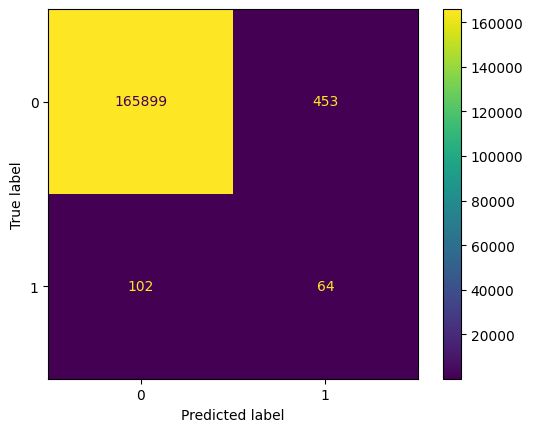

In [38]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Supongamos que quieres usar 0.5 como umbral
umbral = 0.9875
df_4['prediccion'] = (df_4['score'] >= umbral).astype(int)

# Matriz de confusión
y_true = df_4['target_m']
y_pred = df_4['prediccion']

cm = confusion_matrix(y_true, y_pred)
print("Matriz de Confusión:")
print(cm)

# Mostrar gráfica (opcional)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot()


Matriz de Confusión:
[[730 184]
 [102  64]]


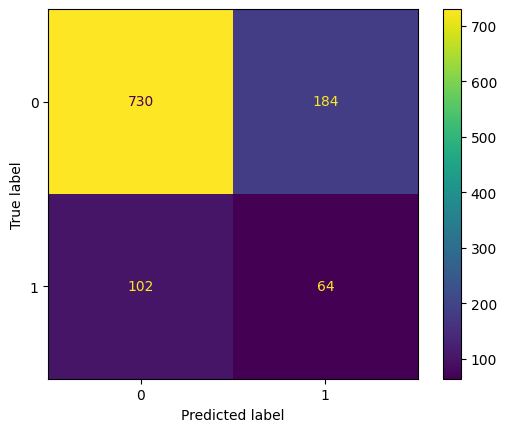

In [39]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Supongamos que quieres usar 0.5 como umbral
umbral = 0.9875
df_7['prediccion'] = (df_7['score'] >= umbral).astype(int)

# Matriz de confusión
y_true = df_7['target_m']
y_pred = df_7['prediccion']

cm = confusion_matrix(y_true, y_pred)
print("Matriz de Confusión:")
print(cm)

# Mostrar gráfica (opcional)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot()

In [33]:
df_4.variable1.value_counts()

variable1
SIN_INFO           806173
AUTOMATICA           2530
MANUAL                984
SEMI AUTOMATICA       279
Name: count, dtype: int64

In [48]:
df_4[['grupo_corte_nueva_alerta','codmes']].value_counts()

grupo_corte_nueva_alerta  codmes
0                         202512    165203
                          202511    163394
                          202510    161921
                          202509    159962
                          202508    158565
1                         202508       203
                          202512       193
                          202509       186
                          202511       178
                          202510       161
Name: count, dtype: int64

In [34]:
df_5= df_4[(df_4.variable1 !='SIN_INFO')]

In [35]:
df_5.codmes.value_counts()

codmes
202510    1459
202509     814
202508     560
202512     510
202511     450
Name: count, dtype: int64

In [36]:
df_res = (
    df_5
    .groupby("grupo_alerta")
    .agg(
        cantidad_casos=("num_documento", "count"),
        suma_target_m=("target_m", "sum")
    )
    .reset_index()
)
df_res

,grupo_alerta,cantidad_casos,suma_target_m
0,P1,752,278
1,P2,760,72
2,P3,770,41
3,P4+P5,1511,31


In [40]:
!pip install seaborn

   codmes grupo_alerta  cantidad_casos  suma_target_m  efectividad_pct
0  202602           P1             517             64            12.38
1  202602           P2            1139             63             5.53
2  202602           P3            4649             28              0.6
3  202602        P4+P5          160213             11             0.01

Efectividad (%) por grupo y mes
codmes        202602
grupo_alerta        
P1             12.38
P2              5.53
P3               0.6
P4+P5           0.01


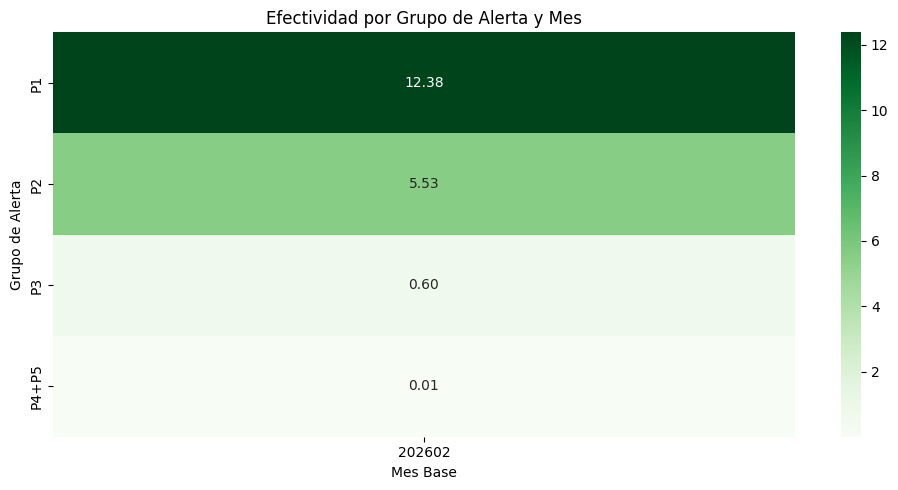

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 1. AGREGACIÓN POR MES Y GRUPO
# =========================
df_res = (
    df_4
    .groupby(["codmes", "grupo_alerta"])
    .agg(
        cantidad_casos=("num_documento", "count"),
        suma_target_m=("target_m", "sum")
    )
    .reset_index()
)

# =========================
# 2. EFECTIVIDAD
# =========================
df_res["efectividad"] = df_res["suma_target_m"] / df_res["cantidad_casos"]

# =========================
# 3. TABLA DE RESULTADOS (LEGIBLE)
# =========================
df_view = df_res.copy()
df_view["efectividad_pct"] = (df_view["efectividad"] * 100).round(2)

print(
    df_view
    .sort_values(["codmes", "grupo_alerta"])
    [["codmes", "grupo_alerta", "cantidad_casos", "suma_target_m", "efectividad_pct"]]
)

# =========================
# 4. PIVOT PARA INSIGHT
# =========================
pivot_efectividad = (
    df_res
    .pivot(index="grupo_alerta", columns="codmes", values="efectividad")
    * 100
).round(2)

print("\nEfectividad (%) por grupo y mes")
print(pivot_efectividad)

# =========================
# 5. HEATMAP (VISUAL)
# =========================
plt.figure(figsize=(10, 5))
sns.heatmap(
    pivot_efectividad,
    annot=True,
    fmt=".2f",
    cmap="Greens"
)
plt.title("Efectividad por Grupo de Alerta y Mes")
plt.ylabel("Grupo de Alerta")
plt.xlabel("Mes Base")
plt.tight_layout()
plt.show()

In [43]:
df_5= df_4

   codmes grupo_alerta  cantidad_casos  suma_target_m  efectividad_pct
0  202602           P1             517             64            12.38
1  202602           P2            1139             63             5.53
2  202602           P3            4649             28              0.6
3  202602        P4+P5          160213             11             0.01

Efectividad (%) por grupo y mes
codmes        202602
grupo_alerta        
P1             12.38
P2              5.53
P3               0.6
P4+P5           0.01


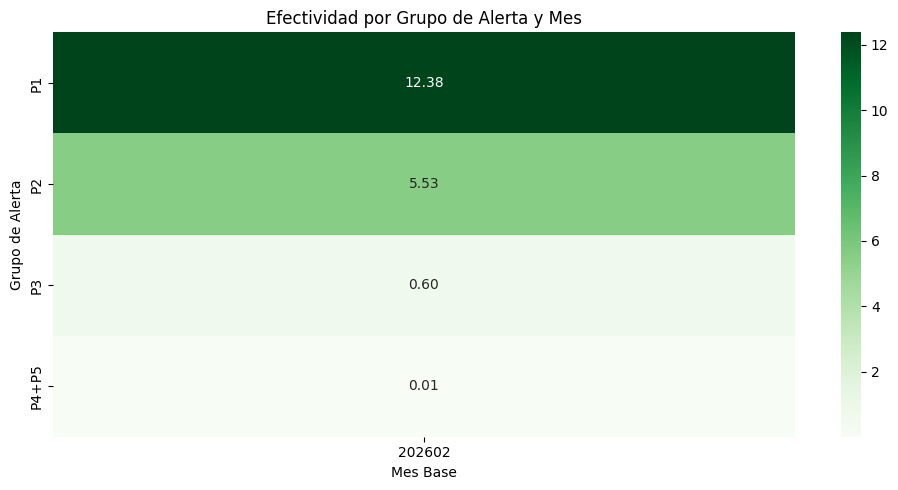

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 1. AGREGACIÓN POR MES Y GRUPO
# =========================
df_res = (
    df_5
    .groupby(["codmes", "grupo_alerta"])
    .agg(
        cantidad_casos=("num_documento", "count"),
        suma_target_m=("target_m", "sum")
    )
    .reset_index()
)

# =========================
# 2. EFECTIVIDAD
# =========================
df_res["efectividad"] = df_res["suma_target_m"] / df_res["cantidad_casos"]

# =========================
# 3. TABLA DE RESULTADOS (LEGIBLE)
# =========================
df_view = df_res.copy()
df_view["efectividad_pct"] = (df_view["efectividad"] * 100).round(2)

print(
    df_view
    .sort_values(["codmes", "grupo_alerta"])
    [["codmes", "grupo_alerta", "cantidad_casos", "suma_target_m", "efectividad_pct"]]
)

# =========================
# 4. PIVOT PARA INSIGHT
# =========================
pivot_efectividad = (
    df_res
    .pivot(index="grupo_alerta", columns="codmes", values="efectividad")
    * 100
).round(2)

print("\nEfectividad (%) por grupo y mes")
print(pivot_efectividad)

# =========================
# 5. HEATMAP (VISUAL)
# =========================
plt.figure(figsize=(10, 5))
sns.heatmap(
    pivot_efectividad,
    annot=True,
    fmt=".2f",
    cmap="Greens"
)
plt.title("Efectividad por Grupo de Alerta y Mes")
plt.ylabel("Grupo de Alerta")
plt.xlabel("Mes Base")
plt.tight_layout()
plt.show()


In [48]:
df_final.head()

,codmes,num_documento,codunico,modelo,fec_replica,grupo_alerta,grupo_corte_nueva_alerta,score,orden,variable1,variable2,variable3
0,202602,F15DA02D8588DD586391F7118A4D6A12C8F4DACA69980B...,21927707,plaft_pj_minorista,20260304,P1,0,0.999433,1,AUTOMATICA,NaN,NaN
1,202602,159F32013DD1D80571DAE6BCC0CE0A83C419C570417F1F...,21592097,plaft_pj_minorista,20260304,P1,0,0.999356,2,AUTOMATICA,NaN,NaN
2,202602,F9DB87158E8417CEFC2CA5130BB7C678211A974A595C79...,21343165,plaft_pj_minorista,20260304,P1,0,0.999333,3,AUTOMATICA,NaN,NaN
3,202602,E8EA23A68171C27D3E019A28D7BFE23ABADD755129FB4C...,21455749,plaft_pj_minorista,20260304,P1,0,0.999327,4,AUTOMATICA,NaN,NaN
4,202602,8BD2560B97446AB81A21534DD0053941F89D6CBDB9CF9B...,17732743,plaft_pj_minorista,20260304,P1,0,0.999302,5,AUTOMATICA,NaN,NaN


In [49]:
df_final_sin_alerta= df_final[(df_final.grupo_corte_nueva_alerta != 0)]

In [50]:
df_res = (
    df_final_sin_alerta
    .groupby(['grupo_alerta', 'codmes'], as_index=False)
    .size()
    .rename(columns={'size': 'cantidad'})
    .pivot(index='grupo_alerta', columns='codmes', values='cantidad')
    .fillna(0)
    .astype(int)
)

df_res['TOTAL'] = df_res.sum(axis=1)
df_res = df_res.sort_values('TOTAL', ascending=False)

print(df_res)

codmes        202602  TOTAL
grupo_alerta               
P1               123    123


In [45]:
df_res = (
    df_5
    .groupby(["mes_base", "grupo_alerta"])
    .agg(
        cantidad_casos=("num_documento", "count"),
        suma_target_m=("target_m", "sum")
    )
    .reset_index()
)

# Efectividad
df_res["efectividad"] = (
    df_res["suma_target_m"] / df_res["cantidad_casos"]
)


KeyError: 'mes_base'

In [46]:
df_res["efectividad_pct"] = df_res["efectividad"] * 100

In [40]:
df_efec_p13 = (
    df_res[df_res["grupo_alerta"].isin(["P1", "P2", "P3"])]
    .groupby("mes_base")
    .agg(efectividad_prom=("efectividad", "mean"))
    .reset_index()
)


KeyError: 'mes_base'

In [41]:
df_res.sort_values(["mes_base", "grupo_alerta"])


KeyError: 'mes_base'

In [9]:
df_all = pd.concat([df_2, df_1], ignore_index=True)

In [47]:
# =================================================================
# CANTIDAD DE CLIENTES POR MES EN CADA GRUPO
# =================================================================
print("="*70)
print("CANTIDAD DE CLIENTES POR MES - GRUPO ALERTA Y CORTE 0.5")
print("="*70)

# Aseguramos tipos correctos
df_all['codmes'] = df_all['codmes'].astype(str)
df_all['score'] = pd.to_numeric(df_all['score'], errors='coerce')

# Recalculamos grupo_corte_0.5 por si acaso
df_all['grupo_corte_0.5'] = (df_all['score'] > 0.5).astype(int)

# Convertimos grupo_alerta a número si es string
if df_all['grupo_alerta'].dtype == 'object':
    mapping = {'P1':1, 'P2':2, 'P3':3, 'P4+P5':4,
               'Top 20% más riesgoso':1, '2do 20%':2, '3ro 20%':3, '4to 20%':4}
    df_all['grupo_alerta_num'] = df_all['grupo_alerta'].map(mapping)
else:
    df_all['grupo_alerta_num'] = pd.to_numeric(df_all['grupo_alerta'], errors='coerce')

# Tabla final: cantidad por mes y grupo
tabla = df_all.groupby('codmes').agg(
    Total_Clientes=('num_documento', 'nunique'),
    Score_Mayor_05=('grupo_corte_0.5', 'sum'),
    Grupo_1_Top20=('grupo_alerta_num', lambda x: (x==1).sum()),
    Grupo_2=('grupo_alerta_num', lambda x: (x==2).sum()),
    Grupo_3=('grupo_alerta_num', lambda x: (x==3).sum()),
    Grupo_4=('grupo_alerta_num', lambda x: (x==4).sum()),
).reset_index()

# Ordenar meses
tabla = tabla.sort_values('codmes')

print(tabla.to_string(index=False))

CANTIDAD DE CLIENTES POR MES - GRUPO ALERTA Y CORTE 0.5


NameError: name 'df_all' is not defined

In [48]:
df_all_1= df_all[(df_all.variable1 !='0')]
df_all_2= df_all_1[(df_all_1.variable1 !=0)]
# =================================================================
# CANTIDAD POR MES - SOLO CLIENTES CON ALERTA HISTÓRICA (variable1 != '0')
# =================================================================
print("="*80)
print("CLIENTES CON ALERTA HISTÓRICA (variable1 != '0')")
print("="*80)

# Filtrar solo clientes con historial de alerta
df_con_alerta = df_all_2[df_all_2['variable1'].astype(str) != '0'].copy()

# Aseguramos tipos
df_con_alerta['codmes'] = df_con_alerta['codmes'].astype(str)
df_con_alerta['score'] = pd.to_numeric(df_con_alerta['score'], errors='coerce')
df_con_alerta['grupo_corte_0.5'] = (df_con_alerta['score'] > 0.5).astype(int)

# Convertir grupo_alerta a número si es necesario
if df_con_alerta['grupo_alerta'].dtype == 'object':
    mapping = {'P1':1, 'P2':2, 'P3':3, 'P4+P5':4,
               'Top 20% más riesgoso':1, '2do 20%':2, '3ro 20%':3, '4to 20%':4}
    df_con_alerta['grupo_alerta_num'] = df_con_alerta['grupo_alerta'].map(mapping)
else:
    df_con_alerta['grupo_alerta_num'] = pd.to_numeric(df_con_alerta['grupo_alerta'], errors='coerce')

# Tabla final
tabla_filtrada = df_con_alerta.groupby('codmes').agg(
    Total_Con_Alerta=('num_documento', 'nunique'),
    Score_Mayor_05=('grupo_corte_0.5', 'sum'),
    Grupo_1_Top20=('grupo_alerta_num', lambda x: (x==1).sum()),
    Grupo_2=('grupo_alerta_num', lambda x: (x==2).sum()),
    Grupo_3=('grupo_alerta_num', lambda x: (x==3).sum()),
    Grupo_4=('grupo_alerta_num', lambda x: (x==4).sum()),
).astype(int).reset_index()

tabla_filtrada = tabla_filtrada.sort_values('codmes')
print(tabla_filtrada.to_string(index=False))



CLIENTES CON ALERTA HISTÓRICA (variable1 != '0')
codmes  Total_Con_Alerta  Score_Mayor_05  Grupo_1_Top20  Grupo_2  Grupo_3  Grupo_4
202508               549              85            103      108      112      230
202512               435              39             49       82      112      193


In [54]:
# ========================================
# Crear stats por mes (para variación)
# ========================================
stats = (
    df_all
    .groupby('codmes')
    .agg(
        total=('score', 'count'),
        pct_mayor_05=('score', lambda x: (x > 0.5).mean() * 100)
    )
)

print("\n=== STATS POR MES ===")
print(stats)


=== STATS POR MES ===
         total  pct_mayor_05
codmes                      
202508  161909      0.143908
202512  165400      0.167473


In [55]:
print("\n=== ESTABILIDAD DEL SCORE (PSI Y VARIACIÓN) ===")

def psi(expected, actual, buckets=10):
    expected_perc = np.histogram(expected, bins=buckets, range=(0,1))[0] / len(expected)
    actual_perc = np.histogram(actual, bins=buckets, range=(0,1))[0] / len(actual)
    expected_perc = np.where(expected_perc == 0, 0.0001, expected_perc)
    actual_perc = np.where(actual_perc == 0, 0.0001, actual_perc)
    psi_value = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))
    return psi_value

# Usamos el primer mes como referencia
mes_ref = df_all['codmes'].min()
ref_scores = df_all[df_all['codmes'] == mes_ref]['score']

psi_results = []
for mes in sorted(df_all['codmes'].unique()):
    if mes == mes_ref:
        psi_results.append({'codmes': mes, 'PSI': 0.0, 'var_pct_mayor05': 0.0})
        continue
    actual_scores = df_all[df_all['codmes'] == mes]['score']
    psi_val = psi(ref_scores, actual_scores)
    var_pct = (stats.loc[mes, 'pct_mayor_05'] / stats.loc[mes_ref, 'pct_mayor_05'] - 1) * 100
    psi_results.append({'codmes': mes, 'PSI': round(psi_val, 4), 'var_pct_mayor05': round(var_pct, 2)})

psi_df = pd.DataFrame(psi_results)
print(psi_df)

# Interpretación automática
print("\nInterpretación PSI:")
for _, row in psi_df.iterrows():
    if row['PSI'] < 0.1:
        print(f"{row['codmes']}: PSI = {row['PSI']} → ESTABLE")
    elif row['PSI'] < 0.25:
        print(f"{row['codmes']}: PSI = {row['PSI']} → Monitorear")
    else:
        print(f"{row['codmes']}: PSI = {row['PSI']} → INESTABLE (revisar modelo)")


=== ESTABILIDAD DEL SCORE (PSI Y VARIACIÓN) ===
   codmes     PSI  var_pct_mayor05
0  202508  0.0000             0.00
1  202512  0.0002            16.37

Interpretación PSI:
202508: PSI = 0.0 → ESTABLE
202512: PSI = 0.0002 → ESTABLE


In [11]:
import pandas as pd

import pandas as pd

# ===============================================================
# 1. Parámetros de tu bucket y prefijo
# ===============================================================
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PJ/MINORISTA'

# Ejemplo completo:
# bucket_name  = "sagemaker-us-east-1-123456789012"
# model_prefix = "risk-fraud-model/2025-12-05"

# ===============================================================
# 2. Rutas en S3
# ===============================================================
base_s3_path = f"s3://{bucket_name}/{model_prefix}/data_dev_model"

headers_path      = f"{base_s3_path}/headers.csv"
train_path        = f"{base_s3_path}/train.csv"
val_path          = f"{base_s3_path}/validation.csv"
test_path         = f"{base_s3_path}/test.csv"
extras_val_path   = f"{base_s3_path}/extras_validation.csv"
extras_test_path  = f"{base_s3_path}/extras_test.csv"

# ===============================================================
# 3. Cargar headers (orden y tipos)
# ===============================================================
headers = pd.read_csv(headers_path)
column_order = headers['variables'].tolist()

print(f"Se cargaron {len(column_order)} variables desde S3")
print("Primeras 10 variables:", column_order[:10])

# ===============================================================
# 4. Cargar train / val / test SIN header, pero CON nombres correctos
# ===============================================================
df_train = pd.read_csv(train_path, header=None, names=column_order)
df_val   = pd.read_csv(val_path,   header=None, names=column_order)
df_test  = pd.read_csv(test_path,  header=None, names=column_order)

print(f"\nShapes cargados desde S3:")
print(f"  Train : {df_train.shape}")
print(f"  Val   : {df_val.shape}")
print(f"  Test  : {df_test.shape}")

# ===============================================================
# 5. Cargar extras (num_documento, mes_base, tipo_alerta_n2)
# ===============================================================
extras_val  = pd.read_csv(extras_val_path)
extras_test = pd.read_csv(extras_test_path)

# Pegamos las columnas de reporting al dataframe original
df_val  = pd.concat([df_val.reset_index(drop=True), 
                     extras_val[['num_documento', 'mes_base']]], axis=1)

df_test = pd.concat([df_test.reset_index(drop=True), 
                     extras_test[['num_documento', 'mes_base']]], axis=1)

# ===============================================================
# 6. Verificación final
# ===============================================================
print("\nListo! Todo cargado correctamente desde S3")
print(f"df_val  ahora tiene {df_val.shape[1]} columnas (incluye num_documento y mes_base)")
print(f"df_test ahora tiene {df_test.shape[1]} columnas")

# Ejemplo rápido de uso
display(df_val[['num_documento', 'mes_base', 'target']].head())


Se cargaron 31 variables desde S3
Primeras 10 variables: ['target', 'codunico', 'codmes_lag1', 'pasivo_soles', 'trx_monto_abonos_6m_efectivo', 'trx_monto_cargos_6m_efectivo', 'trx_monto_cargos_promedio_3m_total', 'trx_monto_abonos_3m_max', 'trx_q_cargos_3m_total', 'trx_q_abonos_promedio_3m_total']

Shapes cargados desde S3:
  Train : (113900, 31)
  Val   : (56100, 31)
  Test  : (644322, 31)

Listo! Todo cargado correctamente desde S3
df_val  ahora tiene 33 columnas (incluye num_documento y mes_base)
df_test ahora tiene 33 columnas


,num_documento,mes_base,target
0,F14E0C7F3F2C493C605C00BA468619460B8E4AE71D1129...,202504.0,0.0
1,48144837D226CEF4F133315DF7C5F2A06B5F7F41A6FBC9...,202507.0,0.0
2,F23D144F5D73C9EEF079DFF7056AAE896D9A80A01AF334...,202503.0,0.0
3,7C197505491ACCCB3E86EC34174F2B614F96DF16F9CA74...,202505.0,0.0
4,78AE54B841EFD3444DA4FE8884150663FD287ACE383949...,202502.0,0.0


In [12]:
df_2.head()

,codmes,num_documento,codunico,modelo,fec_replica,grupo_alerta,grupo_corte_0.5,score,orden,variable1,variable2,variable3
0,202508,D6633A8E1870698C5F8BD1A006BE156B88D18D5EDD822E...,17151953,plaft_pj_minorista,20260128,P4+P5,0,0.000067,1,0,NaN,NaN
1,202508,2C25756DDEA50A845284BE1534A1311440CBC325886B84...,19133902,plaft_pj_minorista,20260128,P4+P5,0,0.000067,2,0,NaN,NaN
2,202508,29466B1FF10613F2DB3C761C1851F36854A8D41F844F57...,17766407,plaft_pj_minorista,20260128,P4+P5,0,0.000064,3,0,NaN,NaN
3,202508,11EB844377FF213FE31AFDA3B046077EE233C9DB571E63...,18040828,plaft_pj_minorista,20260128,P4+P5,0,0.000063,4,0,NaN,NaN
4,202508,38F654B81AC14D5241A9179566143012A5BBE6C26C3E4A...,18729466,plaft_pj_minorista,20260128,P4+P5,0,0.000063,5,0,NaN,NaN


In [13]:
# Cantidad de casos con score > 0.5 por mes
conteo_mayor_05 = df_2[df_2["score"] > 0.5] \
                     .groupby("codmes") \
                     .size()

print(conteo_mayor_05)

Series([], dtype: int64)


In [14]:
df_test.mes_base.value_counts()

mes_base
202511.0    163556
202510.0    161893
202509.0    160124
202508.0    158749
Name: count, dtype: int64

In [15]:
df_2.head()

,codmes,num_documento,codunico,modelo,fec_replica,grupo_alerta,grupo_corte_0.5,score,orden,variable1,variable2,variable3
0,202508,D6633A8E1870698C5F8BD1A006BE156B88D18D5EDD822E...,17151953,plaft_pj_minorista,20260128,P4+P5,0,0.000067,1,0,NaN,NaN
1,202508,2C25756DDEA50A845284BE1534A1311440CBC325886B84...,19133902,plaft_pj_minorista,20260128,P4+P5,0,0.000067,2,0,NaN,NaN
2,202508,29466B1FF10613F2DB3C761C1851F36854A8D41F844F57...,17766407,plaft_pj_minorista,20260128,P4+P5,0,0.000064,3,0,NaN,NaN
3,202508,11EB844377FF213FE31AFDA3B046077EE233C9DB571E63...,18040828,plaft_pj_minorista,20260128,P4+P5,0,0.000063,4,0,NaN,NaN
4,202508,38F654B81AC14D5241A9179566143012A5BBE6C26C3E4A...,18729466,plaft_pj_minorista,20260128,P4+P5,0,0.000063,5,0,NaN,NaN


In [16]:
df_2.head()

,codmes,num_documento,codunico,modelo,fec_replica,grupo_alerta,grupo_corte_0.5,score,orden,variable1,variable2,variable3
0,202508,D6633A8E1870698C5F8BD1A006BE156B88D18D5EDD822E...,17151953,plaft_pj_minorista,20260128,P4+P5,0,0.000067,1,0,NaN,NaN
1,202508,2C25756DDEA50A845284BE1534A1311440CBC325886B84...,19133902,plaft_pj_minorista,20260128,P4+P5,0,0.000067,2,0,NaN,NaN
2,202508,29466B1FF10613F2DB3C761C1851F36854A8D41F844F57...,17766407,plaft_pj_minorista,20260128,P4+P5,0,0.000064,3,0,NaN,NaN
3,202508,11EB844377FF213FE31AFDA3B046077EE233C9DB571E63...,18040828,plaft_pj_minorista,20260128,P4+P5,0,0.000063,4,0,NaN,NaN
4,202508,38F654B81AC14D5241A9179566143012A5BBE6C26C3E4A...,18729466,plaft_pj_minorista,20260128,P4+P5,0,0.000063,5,0,NaN,NaN


In [17]:
df_test['codmes']= df_test.mes_base.astype('int64')

In [18]:
df_3 = pd.merge(df_2, df_test, left_on=['num_documento','codmes'], right_on=['num_documento','codmes'], how='inner')

In [19]:
df_3.head()

,codmes,num_documento,codunico_x,modelo,fec_replica,grupo_alerta,grupo_corte_0.5,score,orden,variable1,...,sectorista_id,ciiu_v4,flag_casos_hist,flag_variacion_abono_monto_total_5m_1m,flag_variacion_efect_cargos_monto_5m_1m,q_ro_debajo_umbral,q_alerta_hist,q_ros_hist,tipo_alerta_n2,mes_base
0,202508,D6633A8E1870698C5F8BD1A006BE156B88D18D5EDD822E...,17151953,plaft_pj_minorista,20260128,P4+P5,0,0.000067,1,0,...,64,250,0,0,0,0.0,0.0,0.0,0,202508.0
1,202508,2C25756DDEA50A845284BE1534A1311440CBC325886B84...,19133902,plaft_pj_minorista,20260128,P4+P5,0,0.000067,2,0,...,398,193,0,1,0,0.0,0.0,0.0,0,202508.0
2,202508,29466B1FF10613F2DB3C761C1851F36854A8D41F844F57...,17766407,plaft_pj_minorista,20260128,P4+P5,0,0.000064,3,0,...,398,176,0,0,0,0.0,0.0,0.0,0,202508.0
3,202508,11EB844377FF213FE31AFDA3B046077EE233C9DB571E63...,18040828,plaft_pj_minorista,20260128,P4+P5,0,0.000063,4,0,...,427,250,0,0,0,0.0,0.0,0.0,0,202508.0
4,202508,38F654B81AC14D5241A9179566143012A5BBE6C26C3E4A...,18729466,plaft_pj_minorista,20260128,P4+P5,0,0.000063,5,0,...,398,250,0,0,0,0.0,0.0,0.0,0,202508.0


In [20]:
###Tabla_Deciles

def Tabla_Deciles(objective,probas,n=10):
    data={'Objective':objective}
    df_deciles=pd.DataFrame(data,columns=['Objective'])
    df_deciles['probas']=probas
    df_deciles['Rangos']=pd.qcut(df_deciles['probas'],n,duplicates='drop')
    cross_tab=pd.crosstab(df_deciles['Rangos'],df_deciles['Objective'],rownames=['Rangos'],colnames=['Objective'])
    a=0;b=1
    cross_tab['Efectividad']=(cross_tab[1]/cross_tab[[0,1]].sum(axis=1))
    cross_tab['%CumSum_{}'.format(a)]=cross_tab[a].cumsum()/cross_tab[a].sum()
    cross_tab['%CumSum_{}'.format(b)]=cross_tab.loc[::-1,b].cumsum()[::-1]/cross_tab[b].sum()
    cross_tab['CumSum_{}'.format(a)]=cross_tab[a].cumsum()
    cross_tab['CumSum_{}'.format(b)]=cross_tab.loc[::-1,b].cumsum()[::-1]
    return cross_tab

In [21]:
df_5=df_3

In [22]:
df_5[["target"]].value_counts()

target
0.0       158636
1.0          112
Name: count, dtype: int64

In [23]:
y_test=df_5.target

In [24]:
y_test['prob'] = df_5.score
y_test['decil'] = (pd.qcut(y_test.prob, 10, labels=False)-10)*-1

/tmp/ipykernel_11310/1092124540.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test['prob'] = df_5.score


In [25]:
y_test['Rangos']=pd.qcut(y_test['prob'],10,duplicates='drop')

In [26]:
Tabla_Deciles(df_5['target'],y_test['prob'],n=10)

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.0009999729, 8.71e-07]",15853,22,0.001386,0.099933,1.000000,15853,112
"(8.71e-07, 1.27e-06]",15863,18,0.001133,0.199929,0.803571,31716,90
"(1.27e-06, 1.83e-06]",15948,16,0.001002,0.300461,0.642857,47664,72
"(1.83e-06, 2.5e-06]",15823,21,0.001325,0.400206,0.500000,63487,56
"(2.5e-06, 2.92e-06]",15861,1,0.000063,0.500189,0.312500,79348,35
"(2.92e-06, 3.82e-06]",15813,10,0.000632,0.599870,0.303571,95161,34
"(3.82e-06, 4.93e-06]",19158,7,0.000365,0.720637,0.214286,114319,24
"(4.93e-06, 6.29e-06]",12658,8,0.000632,0.800430,0.151786,126977,17
"(6.29e-06, 1.22e-05]",15878,9,0.000567,0.900521,0.080357,142855,9


In [27]:
Tabla_Deciles(df_5['target'],y_test['prob'],n=1000)

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-7.294701999999999e-08, 3.629477e-07]",159,0,0.000000,0.001002,1.000000,159,112
"(3.629477e-07, 4.129221e-07]",163,1,0.006098,0.002030,1.000000,322,112
"(4.129221e-07, 4.413831e-07]",154,0,0.000000,0.003001,0.991071,476,111
"(4.413831e-07, 4.696738e-07]",202,2,0.009804,0.004274,0.991071,678,111
"(4.696738e-07, 4.825923e-07]",121,0,0.000000,0.005037,0.973214,799,109
...,...,...,...,...,...,...,...
"(3.773114e-05, 3.901827e-05]",159,0,0.000000,0.996010,0.000000,158003,0
"(3.901827e-05, 4.058293e-05]",157,0,0.000000,0.996999,0.000000,158160,0
"(4.058293e-05, 4.230275e-05]",158,0,0.000000,0.997995,0.000000,158318,0


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(df_5.target,  y_test.prob)
roc_auc = auc(fpr, tpr)
print('Ensemble Area under the ROC curve test : %f' % roc_auc)
print('Ensemble Gini value test : %f' % ((roc_auc*2-1)*100))

Ensemble Area under the ROC curve test : 0.343344
Ensemble Gini value test : -31.331273


In [29]:
test_data_0825_alerta= df_5[(df_5.variable1 !='0')]

In [30]:
test_data_0825_alerta_1= test_data_0825_alerta[(test_data_0825_alerta.variable1 !=0)]

In [31]:
df_res = test_data_0825_alerta_1.groupby('grupo_alerta').agg({'num_documento':len}).reset_index()
df_res

,grupo_alerta,num_documento
0,P4+P5,540


In [32]:
test_data_0825_alerta_1.shape

(540, 44)

In [33]:
y_test=test_data_0825_alerta_1.target

In [34]:
y_test.shape

(540,)

In [35]:
y_test['prob'] = test_data_0825_alerta_1.score
#y_test['decil'] = (pd.qcut(y_test.prob, 10, labels=False)-10)*-1

/tmp/ipykernel_11310/3435642817.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test['prob'] = test_data_0825_alerta_1.score
/tmp/ipykernel_11310/3435642817.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test['prob'] = test_data_0825_alerta_1.score


In [36]:
y_test['Rangos']=pd.qcut(y_test['prob'],5,duplicates='drop')

/tmp/ipykernel_11310/1756741874.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test['Rangos']=pd.qcut(y_test['prob'],5,duplicates='drop')
/tmp/ipykernel_11310/1756741874.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test['Rangos']=pd.qcut(y_test['prob'],5,duplicates='drop')


In [37]:
Tabla_Deciles(test_data_0825_alerta_1['target'],test_data_0825_alerta_1['score'],n=5)

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.0009999728, 7.46e-07]",96,13,0.119266,0.224299,1.000000,96,112
"(7.46e-07, 9.8e-07]",94,13,0.121495,0.443925,0.883929,190,99
"(9.8e-07, 1.32e-06]",94,14,0.129630,0.663551,0.767857,284,86
"(1.32e-06, 2.76e-06]",70,38,0.351852,0.827103,0.642857,354,72
"(2.76e-06, 1.88e-05]",74,34,0.314815,1.000000,0.303571,428,34


In [292]:
# Control puntos de cortes

In [103]:
import pandas as pd
import numpy as np
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PJ/MINORISTA'

df = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_Plaft-PJ-Minorista_202507.txt'.format(bucket_name, model_prefix ), sep= '|')


/tmp/ipykernel_12044/391166737.py:6: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_Plaft-PJ-Minorista_202507.txt'.format(bucket_name, model_prefix ), sep= '|')


In [104]:
import pandas as pd
import numpy as np
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PJ/MINORISTA'

df_1 = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_Plaft-PJ-Minorista_202508.txt'.format(bucket_name, model_prefix ), sep= '|')

/tmp/ipykernel_12044/2266279170.py:6: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_1 = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_Plaft-PJ-Minorista_202508.txt'.format(bucket_name, model_prefix ), sep= '|')


In [105]:
import pandas as pd
import numpy as np
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PJ/MINORISTA'

df_2 = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_Plaft-PJ-Minorista_202509.txt'.format(bucket_name, model_prefix ), sep= '|')

/tmp/ipykernel_12044/1973552465.py:6: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2 = pd.read_csv('s3://{}/{}/REPLICA_OUTPUT/scr_Plaft-PJ-Minorista_202509.txt'.format(bucket_name, model_prefix ), sep= '|')


In [106]:
df_2.head()

,codmes,num_documento,codunico,modelo,fec_replica,grupo_alerta,grupo_corte_0.5,score,orden,variable1,variable2,variable3
0,202509,C3DD251BB58D37B4D4636CAC2A19D6678CF222EFD52EF6...,21728054,plaft_pj_minorista,20251216,P1,1,0.998502,1,0,NaN,NaN
1,202509,493EB0F435E8A85CEFAAB1C42570719DC72992E0DBDC1F...,21723470,plaft_pj_minorista,20251216,P1,1,0.996069,2,AUTOMATICA,NaN,NaN
2,202509,31AA4CC07FDAE1DB5043CCD1C2FCECC49D9DD698C08846...,21739949,plaft_pj_minorista,20251216,P1,1,0.994686,3,AUTOMATICA,NaN,NaN
3,202509,7BB88376A25976A168C35C544D4F58B66FCDFBBDEF1BC4...,21678782,plaft_pj_minorista,20251216,P1,1,0.992375,4,0,NaN,NaN
4,202509,B806D2CF15413A25776F325812DC9B2F7C041A5AA86688...,21704502,plaft_pj_minorista,20251216,P1,1,0.992273,5,0,NaN,NaN


In [107]:
df_1.head(10)

,codmes,num_documento,codunico,modelo,fec_replica,grupo_alerta,grupo_corte_0.5,score,orden,variable1,variable2,variable3
0,202508,B806D2CF15413A25776F325812DC9B2F7C041A5AA86688...,21704502,plaft_pj_minorista,20251216,P1,1,0.997901,1,0,NaN,NaN
1,202508,C3DD251BB58D37B4D4636CAC2A19D6678CF222EFD52EF6...,21728054,plaft_pj_minorista,20251216,P1,1,0.996828,2,AUTOMATICA,NaN,NaN
2,202508,7BB88376A25976A168C35C544D4F58B66FCDFBBDEF1BC4...,21678782,plaft_pj_minorista,20251216,P1,1,0.996817,3,SEMI AUTOMATICA,NaN,NaN
3,202508,5D3E7AB553786651888B36DB6049E33680C6A55575A773...,21651580,plaft_pj_minorista,20251216,P1,1,0.996186,4,0,NaN,NaN
4,202508,CC51D6B3F3BF2996D78E05E7C5054FB7406328D647F441...,21665571,plaft_pj_minorista,20251216,P1,1,0.995613,5,AUTOMATICA,NaN,NaN
5,202508,8F7CB8110C300F765DDB9F30A0F77E153FE63389DEBB2B...,21066636,plaft_pj_minorista,20251216,P1,1,0.994143,6,AUTOMATICA,NaN,NaN
6,202508,250CDDB7A2E7F170375768A978ADCFA3E5358D2F1DD4A1...,21570669,plaft_pj_minorista,20251216,P1,1,0.994007,7,MANUAL,NaN,NaN
7,202508,12BBAB56EDAA2EED1FF1586740E73B8F450D4C67795D7B...,21687542,plaft_pj_minorista,20251216,P1,1,0.992973,8,AUTOMATICA,NaN,NaN
8,202508,00E5CF5595BCE6D77598FEE3DA207F5352FB52D7D58EAA...,21563570,plaft_pj_minorista,20251216,P1,1,0.992716,9,AUTOMATICA,NaN,NaN
9,202508,93F5B3C013178B5FFDEF444A8124091C3531752453BC73...,21618417,plaft_pj_minorista,20251216,P1,1,0.990426,10,SEMI AUTOMATICA,NaN,NaN


In [108]:
df_all = pd.concat([df, df_1, df_2], ignore_index=True)

In [109]:
df_all.codmes.value_counts()

codmes
202509    163574
202508    161909
202507    160139
Name: count, dtype: int64

In [110]:
df_all["grupo_corte_0.5"].value_counts()

grupo_corte_0.5
0    484920
1       702
Name: count, dtype: int64

In [111]:
# Cantidad de casos con score > 0.5 por mes
conteo_mayor_05 = df_all[df_all["score"] > 0.5] \
                     .groupby("codmes") \
                     .size()

print(conteo_mayor_05)

codmes
202507    218
202508    233
202509    251
dtype: int64


In [114]:
# =================================================================
# CANTIDAD DE CLIENTES POR MES EN CADA GRUPO
# =================================================================
print("="*70)
print("CANTIDAD DE CLIENTES POR MES - GRUPO ALERTA Y CORTE 0.5")
print("="*70)

# Aseguramos tipos correctos
df_all['codmes'] = df_all['codmes'].astype(str)
df_all['score'] = pd.to_numeric(df_all['score'], errors='coerce')

# Recalculamos grupo_corte_0.5 por si acaso
df_all['grupo_corte_0.5'] = (df_all['score'] > 0.5).astype(int)

# Convertimos grupo_alerta a número si es string
if df_all['grupo_alerta'].dtype == 'object':
    mapping = {'P1':1, 'P2':2, 'P3':3, 'P4+P5':4,
               'Top 20% más riesgoso':1, '2do 20%':2, '3ro 20%':3, '4to 20%':4}
    df_all['grupo_alerta_num'] = df_all['grupo_alerta'].map(mapping)
else:
    df_all['grupo_alerta_num'] = pd.to_numeric(df_all['grupo_alerta'], errors='coerce')

# Tabla final: cantidad por mes y grupo
tabla = df_all.groupby('codmes').agg(
    Total_Clientes=('num_documento', 'nunique'),
    Score_Mayor_05=('grupo_corte_0.5', 'sum'),
    Grupo_1_Top20=('grupo_alerta_num', lambda x: (x==1).sum()),
    Grupo_2=('grupo_alerta_num', lambda x: (x==2).sum()),
    Grupo_3=('grupo_alerta_num', lambda x: (x==3).sum()),
    Grupo_4=('grupo_alerta_num', lambda x: (x==4).sum()),
).reset_index()

# Ordenar meses
tabla = tabla.sort_values('codmes')

print(tabla.to_string(index=False))

CANTIDAD DE CLIENTES POR MES - GRUPO ALERTA Y CORTE 0.5
codmes  Total_Clientes  Score_Mayor_05  Grupo_1_Top20  Grupo_2  Grupo_3  Grupo_4
202507          159797             218            276      621     1243   157999
202508          161572             233            290      624     1252   159743
202509          163265             251            351      725     1274   161224


In [115]:
df_all_1= df_all[(df_all.variable1 !='0')]

In [116]:
df_all_2= df_all_1[(df_all_1.variable1 !=0)]

In [123]:
# =================================================================
# CANTIDAD POR MES - SOLO CLIENTES CON ALERTA HISTÓRICA (variable1 != '0')
# =================================================================
print("="*80)
print("CLIENTES CON ALERTA HISTÓRICA (variable1 != '0')")
print("="*80)

# Filtrar solo clientes con historial de alerta
df_con_alerta = df_all_2[df_all_2['variable1'].astype(str) != '0'].copy()

# Aseguramos tipos
df_con_alerta['codmes'] = df_con_alerta['codmes'].astype(str)
df_con_alerta['score'] = pd.to_numeric(df_con_alerta['score'], errors='coerce')
df_con_alerta['grupo_corte_0.5'] = (df_con_alerta['score'] > 0.5).astype(int)

# Convertir grupo_alerta a número si es necesario
if df_con_alerta['grupo_alerta'].dtype == 'object':
    mapping = {'P1':1, 'P2':2, 'P3':3, 'P4+P5':4,
               'Top 20% más riesgoso':1, '2do 20%':2, '3ro 20%':3, '4to 20%':4}
    df_con_alerta['grupo_alerta_num'] = df_con_alerta['grupo_alerta'].map(mapping)
else:
    df_con_alerta['grupo_alerta_num'] = pd.to_numeric(df_con_alerta['grupo_alerta'], errors='coerce')

# Tabla final
tabla_filtrada = df_con_alerta.groupby('codmes').agg(
    Total_Con_Alerta=('num_documento', 'nunique'),
    Score_Mayor_05=('grupo_corte_0.5', 'sum'),
    Grupo_1_Top20=('grupo_alerta_num', lambda x: (x==1).sum()),
    Grupo_2=('grupo_alerta_num', lambda x: (x==2).sum()),
    Grupo_3=('grupo_alerta_num', lambda x: (x==3).sum()),
    Grupo_4=('grupo_alerta_num', lambda x: (x==4).sum()),
).astype(int).reset_index()

tabla_filtrada = tabla_filtrada.sort_values('codmes')
print(tabla_filtrada.to_string(index=False))

CLIENTES CON ALERTA HISTÓRICA (variable1 != '0')
codmes  Total_Con_Alerta  Score_Mayor_05  Grupo_1_Top20  Grupo_2  Grupo_3  Grupo_4
202507               536              84             95      103      119      220
202508               549              85            103      108      112      230
202509               792              71             92      161      173      366


In [433]:
print("\n=== ESTABILIDAD DEL SCORE (PSI Y VARIACIÓN) ===")

def psi(expected, actual, buckets=10):
    expected_perc = np.histogram(expected, bins=buckets, range=(0,1))[0] / len(expected)
    actual_perc = np.histogram(actual, bins=buckets, range=(0,1))[0] / len(actual)
    expected_perc = np.where(expected_perc == 0, 0.0001, expected_perc)
    actual_perc = np.where(actual_perc == 0, 0.0001, actual_perc)
    psi_value = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))
    return psi_value

# Usamos el primer mes como referencia
mes_ref = df_all['codmes'].min()
ref_scores = df_all[df_all['codmes'] == mes_ref]['score']

psi_results = []
for mes in sorted(df_all['codmes'].unique()):
    if mes == mes_ref:
        psi_results.append({'codmes': mes, 'PSI': 0.0, 'var_pct_mayor05': 0.0})
        continue
    actual_scores = df_all[df_all['codmes'] == mes]['score']
    psi_val = psi(ref_scores, actual_scores)
    var_pct = (stats.loc[mes, 'pct_mayor_05'] / stats.loc[mes_ref, 'pct_mayor_05'] - 1) * 100
    psi_results.append({'codmes': mes, 'PSI': round(psi_val, 4), 'var_pct_mayor05': round(var_pct, 2)})

psi_df = pd.DataFrame(psi_results)
print(psi_df)

# Interpretación automática
print("\nInterpretación PSI:")
for _, row in psi_df.iterrows():
    if row['PSI'] < 0.1:
        print(f"{row['codmes']}: PSI = {row['PSI']} → ESTABLE")
    elif row['PSI'] < 0.25:
        print(f"{row['codmes']}: PSI = {row['PSI']} → Monitorear")
    else:
        print(f"{row['codmes']}: PSI = {row['PSI']} → INESTABLE (revisar modelo)")


=== ESTABILIDAD DEL SCORE (PSI Y VARIACIÓN) ===
   codmes     PSI  var_pct_mayor05
0  202507  0.0000             0.00
1  202508  0.0001             8.62
2  202509  0.0003            13.00

Interpretación PSI:
202507: PSI = 0.0 → ESTABLE
202508: PSI = 0.0001 → ESTABLE
202509: PSI = 0.0003 → ESTABLE


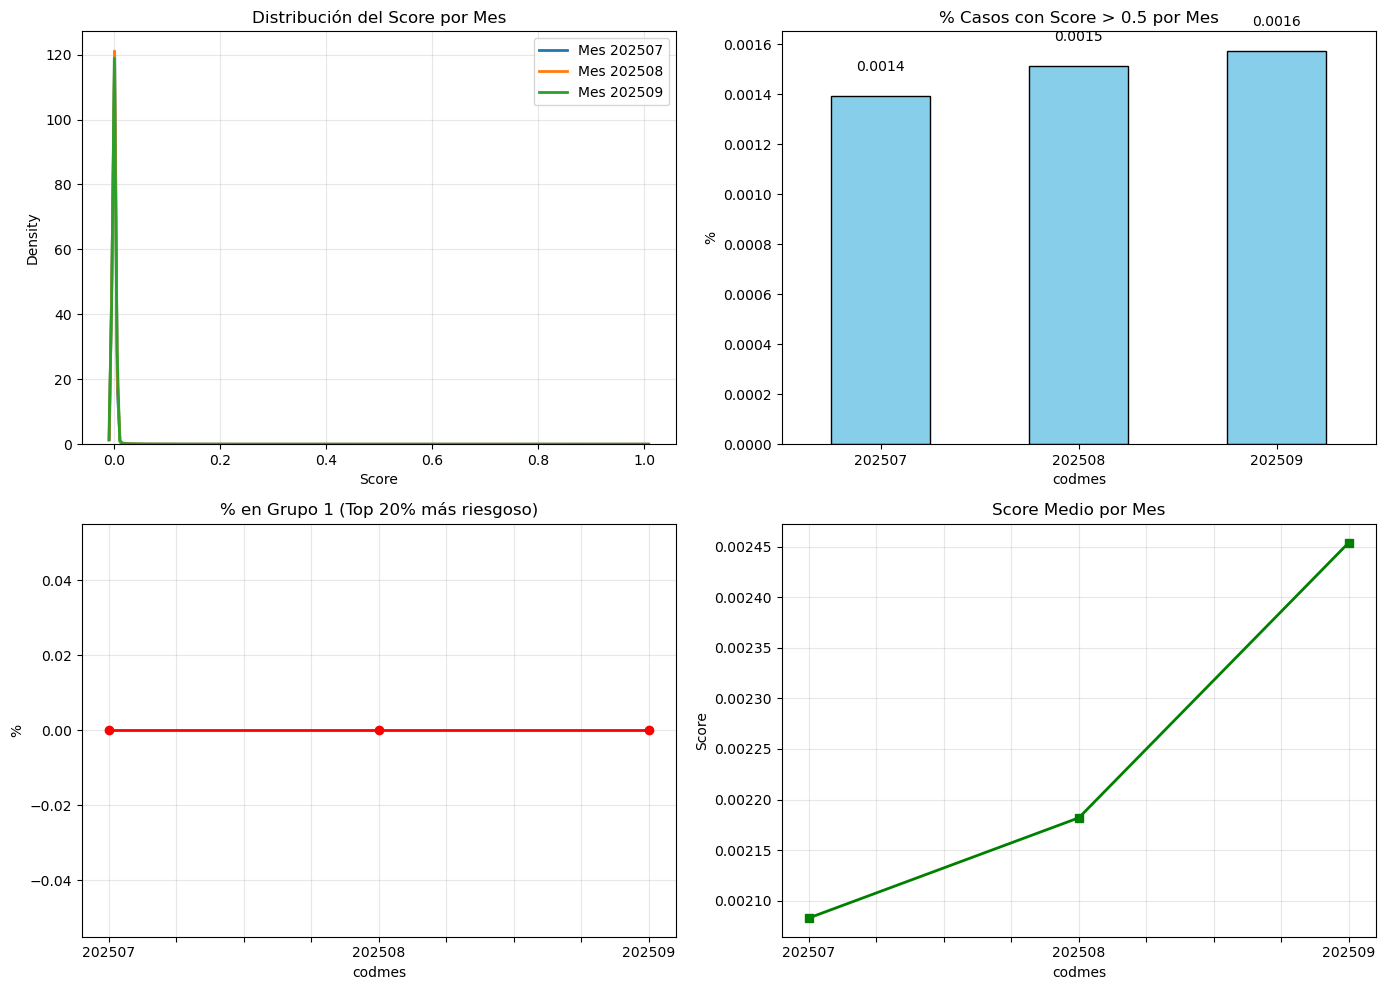

In [434]:
plt.figure(figsize=(14, 10))

# 3.1 Distribución del score por mes
plt.subplot(2, 2, 1)
for mes in sorted(df_all['codmes'].unique()):
    data_mes = df_all[df_all['codmes'] == mes]['score']
    sns.kdeplot(data_mes, label=f'Mes {mes}', linewidth=2)
plt.title('Distribución del Score por Mes')
plt.xlabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)

# 3.2 % de casos > 0.5 por mes
plt.subplot(2, 2, 2)
stats['pct_mayor_05'].plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('% Casos con Score > 0.5 por Mes')
plt.ylabel('%')
plt.xticks(rotation=0)
for i, v in enumerate(stats['pct_mayor_05']):
    plt.text(i, v + 0.0001, f"{v:.4f}", ha='center')

# 3.3 Top 20% (grupo_alerta == 1)
plt.subplot(2, 2, 3)
stats['pct_grupo_1'].plot(kind='line', marker='o', color='red', linewidth=2)
plt.title('% en Grupo 1 (Top 20% más riesgoso)')
plt.ylabel('%')
plt.grid(True, alpha=0.3)

# 3.4 Score medio por mes
plt.subplot(2, 2, 4)
stats['score_medio'].plot(kind='line', marker='s', color='green', linewidth=2)
plt.title('Score Medio por Mes')
plt.ylabel('Score')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [128]:
print("="*90)
print("MIGRACIÓN DE CLIENTES ENTRE GRUPOS DE ALERTA - VERSIÓN FINAL")
print("="*90)

df_all['codmes'] = df_all['codmes'].astype(str)
df_all['num_documento'] = df_all['num_documento'].astype(str)

# CORRECTO: mapeo de strings a números
mapping = {
    'P1': 1, 'P2': 2, 'P3': 3, 'P4+P5': 4, 
    'Top 20% más riesgoso': 1, '2do 20%': 2, '3ro 20%': 3, '4to 20%': 4, 'Bottom 20%': 5
}
df_all['grupo_alerta_num'] = df_all['grupo_alerta'].map(mapping).fillna(99).astype(int)

# Ver cuántos quedaron bien
print(f"Clientes con grupo válido: {(df_all['grupo_alerta_num'] != 99).sum():,}")
print(f"Clientes sin grupo (99): {(df_all['grupo_alerta_num'] == 99).sum():,}\n")

# Pivot
pivot = df_all.pivot_table(index='num_documento', columns='codmes', values='grupo_alerta_num', aggfunc='first')
pivot = pivot.dropna(thresh=2)
print(f"Clientes en al menos 2 meses: {len(pivot):,}\n")

# Migración mes a mes
meses = sorted(pivot.columns)
for i in range(len(meses)-1):
    mes1, mes2 = meses[i], meses[i+1]
    print(f"--- Migración {mes1} → {mes2} ---")
    
    data = pivot[[mes1, mes2]].dropna()
    data = data[(data[mes1] != 99) & (data[mes2] != 99)]
    
    if len(data) == 0:
        print("  → No hay clientes con grupo válido\n")
        continue
    
    migracion = pd.crosstab(data[mes1], data[mes2], margins=True, margins_name="Total →")
    
    # Solo grupos reales
    grupos = sorted(data[mes1].unique())
    grupos = [g for g in grupos if g != 99]
    filas = grupos + ['Total →']
    columnas = grupos + ['Total →']
    migracion = migracion.loc[filas, columnas]
    
    # Nombres bonitos
    nombres = {1: 'P1', 2: 'P2', 3: 'P3', 4: 'P4+P5'}
    migracion.rename(index=nombres, columns=nombres, inplace=True)
    
    print(migracion)
    
    estables = np.diag(migracion.iloc[:-1, :-1]).sum()
    total = migracion.iloc[:-1, -1].sum()
    print(f"  → Estables: {estables:,} ({100*estables/total:.2f}%)")
    print(f"  → Migraron: {total - estables:,}\n")

MIGRACIÓN DE CLIENTES ENTRE GRUPOS DE ALERTA - VERSIÓN FINAL
Clientes con grupo válido: 485,622
Clientes sin grupo (99): 0

Clientes en al menos 2 meses: 161,639

--- Migración 202507 → 202508 ---
202508    P1   P2    P3   P4+P5  Total →
202507                                  
P1       177   72    22       3      274
P2        69  344   169      35      617
P3        25  145   715     347     1232
P4+P5     18   59   340  154273   154690
Total →  289  620  1246  154658   156813
  → Estables: 155,509 (99.17%)
  → Migraron: 1,304

--- Migración 202508 → 202509 ---
202509    P1   P2    P3   P4+P5  Total →
202508                                  
P1       200   67    15       8      290
P2        87  368   133      21      609
P3        21  207   704     306     1238
P4+P5     39   74   417  155636   156166
Total →  347  716  1269  155971   158303
  → Estables: 156,908 (99.12%)
  → Migraron: 1,395



In [76]:
variables_importantes = ['codmes','codunico',	'modelo',	'fec_replica',	'grupo_alerta',	'grupo_corte_0.5',	'score',
"antiguedad",
    "pasivo_soles",                         
 "trx_monto_cargos_6m_efectivo",
                          "trx_q_abonos_ratio_3m_efectivo_total",
                             "q_meses_ingresos_0"
 
]

In [77]:
test_data_0825_sinalerta = df_5[(df_5["variable1"] == '0') | (df_5["variable1"] == 0)
]

In [78]:
test_data_0825_sinalerta_1 = test_data_0825_sinalerta[variables_importantes]

In [79]:
import pandas as pd

pd.set_option('display.max_columns', None)

test_data_0825_sinalerta_1.head(10)

,codmes,codunico,modelo,fec_replica,grupo_alerta,grupo_corte_0.5,score,antiguedad,pasivo_soles,trx_monto_cargos_6m_efectivo,trx_q_abonos_ratio_3m_efectivo_total,q_meses_ingresos_0
0,202508,21704502,plaft_pj_minorista,20251216,P1,1,0.997901,0.0,5.1400,2525186.0,0.8362,9.0
4,202508,21651580,plaft_pj_minorista,20251216,P1,1,0.996186,0.0,52.2473,10582.0,0.0000,9.0
14,202508,21471280,plaft_pj_minorista,20251216,P1,1,0.981914,0.0,0.7000,1963988.8,0.9683,6.0
18,202508,21586985,plaft_pj_minorista,20251216,P1,1,0.975909,0.0,41.2888,34468.9,0.0000,8.0
19,202508,21494933,plaft_pj_minorista,20251216,P1,1,0.974184,0.0,0.0000,536150.0,0.9706,6.0
21,202508,21475150,plaft_pj_minorista,20251216,P1,1,0.968432,0.0,15.7700,6685193.5,0.9516,6.0
25,202508,21590241,plaft_pj_minorista,20251216,P1,1,0.965427,0.0,1169.0414,0.0,0.0000,7.0
27,202508,21555981,plaft_pj_minorista,20251216,P1,1,0.962985,0.0,14970.2800,3456329.0,0.8596,6.0
32,202508,21568076,plaft_pj_minorista,20251216,P1,1,0.956279,0.0,76.7171,15739.4,0.0000,7.0
34,202508,21564628,plaft_pj_minorista,20251216,P1,1,0.955159,0.0,0.0000,1070820.0,0.0000,11.0


In [50]:
 df_3[(df_3["target"] == 1)]

,codmes,num_documento,codunico,modelo,fec_replica,grupo_alerta,grupo_corte_0.5,score,orden,variable1,variable2,variable3,target,pasivo_soles,trx_monto_abonos_6m_efectivo,trx_monto_cargos_6m_efectivo,trx_q_cargos_3m_total,trx_q_abonos_promedio_3m_total,trx_monto_cargos_promedio_3m_total,trx_q_abonos_ratio_1m_efectivo_total,trx_q_abonos_ratio_3m_efectivo_total,trx_q_abonos_ratio_9m_efectivo_total,trx_monto_cargos_ratio_1m_efectivo_total,trx_monto_abonos_3m_max,edad_constitucion,antiguedad,nivel_riesgo_lsb_total,q_meses_ingresos_0,q_meses_egresos_0,provincia,departamento,ubigeo_cd,sectorista_id,ciiu_v4,flag_casos_hist,flag_variacion_abono_monto_total_5m_1m,flag_variacion_efect_cargos_monto_5m_1m,q_ro_debajo_umbral,q_alerta_hist,q_ros_hist,mes_base,tipo_alerta_n2
1,202508,C3DD251BB58D37B4D4636CAC2A19D6678CF222EFD52EF61FC7777601E18D59A5,21728054,plaft_pj_minorista,20251216,P1,1,0.996828,2,AUTOMATICA,NaN,NaN,1.0,722914.2000,0.0,43233.5,185.0,13.00,1.00,0.0000,0.0000,0.0000,0.0002,33967068.00,0.0,0.0,-1.0,10.0,10.0,163,21,644,500,317,0,1,0,0.0,24.0,0.0,202508.0,AUTOMATICA
2,202508,7BB88376A25976A168C35C544D4F58B66FCDFBBDEF1BC4E4740A2ADEDE94F9F1,21678782,plaft_pj_minorista,20251216,P1,1,0.996817,3,SEMI AUTOMATICA,NaN,NaN,1.0,9.6600,5253841.5,2596149.5,685.0,134.67,19.00,0.9905,0.9629,0.9629,0.3708,2325261.20,-1.0,0.0,-1.0,9.0,9.0,29,7,1080,437,393,0,0,0,0.0,2.0,0.0,202508.0,MANUAL
3,202508,7BB88376A25976A168C35C544D4F58B66FCDFBBDEF1BC4E4740A2ADEDE94F9F1,21678782,plaft_pj_minorista,20251216,P1,1,0.996817,3,SEMI AUTOMATICA,NaN,NaN,1.0,9.6600,5253841.5,2596149.5,685.0,134.67,19.00,0.9905,0.9629,0.9629,0.3708,2325261.20,-1.0,0.0,-1.0,9.0,9.0,29,7,1080,437,393,0,0,0,0.0,2.0,0.0,202508.0,SEMI AUTOMATICA
5,202508,CC51D6B3F3BF2996D78E05E7C5054FB7406328D647F44152CF5F67313C62A0E7,21665571,plaft_pj_minorista,20251216,P1,1,0.995613,5,AUTOMATICA,NaN,NaN,1.0,4172.8906,0.0,0.0,41.0,4.33,0.00,0.0000,0.0000,0.0000,0.0000,6141190.00,0.0,0.0,-1.0,10.0,10.0,163,21,644,502,317,0,0,1,0.0,12.0,0.0,202508.0,AUTOMATICA
6,202508,8F7CB8110C300F765DDB9F30A0F77E153FE63389DEBB2B90173B55C82A9BD0C4,21066636,plaft_pj_minorista,20251216,P1,1,0.994143,6,AUTOMATICA,NaN,NaN,1.0,10421.4670,182631.0,940000.0,256.0,9.00,1.33,0.0000,0.3704,0.3704,0.0000,3726511.00,1.0,1.0,-1.0,9.0,9.0,113,15,312,437,318,0,0,0,0.0,1.0,0.0,202508.0,AUTOMATICA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5939,202508,0379A385168DFD6DDDAD8E88E265069E8BF10999AA3A9F955EACDDF95AB60799,11149692,plaft_pj_minorista,20251216,P4+P5,0,0.000640,5922,AUTOMATICA,NaN,NaN,1.0,677073.7000,0.0,11450.0,220.0,6.33,1.00,0.0000,0.0000,0.0000,0.0089,891047.10,21.0,16.0,1.0,0.0,0.0,183,13,174,511,209,0,0,0,0.0,7.0,0.0,202508.0,AUTOMATICA
6048,202508,E4FE93F83985CAC8DC086F9BF23AD9B264EB2CBBE720D569102E821DC4A47F4C,1488790,plaft_pj_minorista,20251216,P4+P5,0,0.000604,6031,AUTOMATICA,NaN,NaN,1.0,345779.6600,5473.9,0.0,168.0,7.33,0.00,0.0000,0.0455,0.0476,0.0000,985726.25,35.0,31.0,1.0,0.0,0.0,86,12,104,37,321,0,0,1,0.0,10.0,2.0,202508.0,AUTOMATICA
8015,202508,79331F4BBFFAB6A604636D2877AFCB983E7F40564DA7E7F57BFB6D2BD71FDA66,13489156,plaft_pj_minorista,20251216,P4+P5,0,0.000212,7997,MANUAL,NaN,NaN,1.0,80.7700,0.0,0.0,97.0,6.00,0.00,0.0000,0.0000,0.0000,0.0000,538253.25,12.0,11.0,1.0,0.0,0.0,113,15,321,27,313,0,0,1,0.0,8.0,0.0,202508.0,MANUAL
8538,202508,2292E77C79D2B44BC9320F6456BAB7FF6B678E87ED5BEC727E989EC0087151B3,17185602,plaft_pj_minorista,20251216,P4+P5,0,0.000157,8520,MANUAL,NaN,NaN,1.0,0.0000,0.0,0.0,0.0,0.00,0.00,0.0000,0.0000,0.0000,0.0000,0.00,5.0,5.0,1.0,12.0,12.0,178,17,417,395,218,0,0,0,0.0,1.0,0.0,202508.0,MANUAL


In [35]:
import numpy as np
import pandas as pd

def nivel_negocio(x, p20, p40, p60, p80):
    if pd.isna(x):
        return "sin dato"
    elif x <= p20:
        return "muy bajo"
    elif x <= p40:
        return "bajo"
    elif x <= p60:
        return "esperado"
    elif x <= p80:
        return "elevado"
    else:
        return "muy elevado"


df_top10 = test_data_0825_sinalerta.head(50).copy()

# Percentiles más suaves (mejor interpretación de negocio)
p = {}
vars_numericas = [
    "trx_monto_abonos_6m_efectivo",
    "trx_monto_cargos_6m_efectivo",
    "trx_q_cargos_3m_total",
    "trx_q_abonos_promedio_3m_total",
    "trx_monto_cargos_promedio_3m_total",
    "trx_monto_abonos_3m_max",
    "antiguedad"
]

for v in vars_numericas:
    p[v] = np.nanpercentile(test_data_0825_sinalerta[v], [20, 40, 60, 80])


def resumen_fila_negocio(row):
    return (
        f"Montos (ing/eg): "
        f"{nivel_negocio(row['trx_monto_abonos_6m_efectivo'], *p['trx_monto_abonos_6m_efectivo'])} / "
        f"{nivel_negocio(row['trx_monto_cargos_6m_efectivo'], *p['trx_monto_cargos_6m_efectivo'])} | "
        f"Frecuencia trx: "
        f"{nivel_negocio(row['trx_q_cargos_3m_total'], *p['trx_q_cargos_3m_total'])} | "
        f"Efectivo: "
        f"{'alto' if row['trx_q_abonos_ratio_3m_efectivo_total'] > 0.7 else 'esperado'} | "
        f"Antigüedad cliente: "
        f"{nivel_negocio(row['antiguedad'], *p['antiguedad'])} | "
        f"Alertas / ROS: "
        f"{'sin eventos relevantes' if row['q_ros_hist'] == 0 else 'con historial'}"
    )


df_top10["descripcion_patron"] = df_top10.apply(resumen_fila_negocio, axis=1)

df_top10[["codunico", "score", "descripcion_patron"]]



,codunico,score,descripcion_patron
0,21704502,0.997901,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: alto | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
4,21651580,0.996186,Montos (ing/eg): muy bajo / muy elevado | Frecuencia trx: muy elevado | Efectivo: esperado | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
14,21471280,0.981914,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: alto | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
18,21586985,0.975909,Montos (ing/eg): elevado / muy elevado | Frecuencia trx: elevado | Efectivo: esperado | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
19,21494933,0.974184,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: alto | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
21,21475150,0.968432,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: alto | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
25,21590241,0.965427,Montos (ing/eg): muy bajo / muy bajo | Frecuencia trx: muy elevado | Efectivo: esperado | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
27,21555981,0.962985,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: alto | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
32,21568076,0.956279,Montos (ing/eg): elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: esperado | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
34,21564628,0.955159,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy bajo | Efectivo: esperado | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes


In [32]:
import pandas as pd

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

df_top10[["codunico", "score", "descripcion_patron"]]


,codunico,score,descripcion_patron
0,21704502,0.997901,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: alto | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
4,21651580,0.996186,Montos (ing/eg): muy bajo / muy elevado | Frecuencia trx: muy elevado | Efectivo: esperado | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
14,21471280,0.981914,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: alto | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
18,21586985,0.975909,Montos (ing/eg): elevado / muy elevado | Frecuencia trx: elevado | Efectivo: esperado | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
19,21494933,0.974184,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: alto | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
21,21475150,0.968432,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: alto | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
25,21590241,0.965427,Montos (ing/eg): muy bajo / muy bajo | Frecuencia trx: muy elevado | Efectivo: esperado | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
27,21555981,0.962985,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: alto | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
32,21568076,0.956279,Montos (ing/eg): elevado / muy elevado | Frecuencia trx: muy elevado | Efectivo: esperado | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes
34,21564628,0.955159,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy bajo | Efectivo: esperado | Antigüedad cliente: muy bajo | Alertas / ROS: sin eventos relevantes


In [33]:
import numpy as np

# =========================
# 1. Funciones de niveles
# =========================

def nivel_monto(x):
    if pd.isna(x) or x <= 0:
        return "muy bajo"
    elif x < 1e5:
        return "bajo"
    elif x < 5e5:
        return "medio"
    elif x < 2e6:
        return "elevado"
    else:
        return "muy elevado"


def nivel_frecuencia(x):
    if pd.isna(x) or x == 0:
        return "muy baja"
    elif x < 10:
        return "baja"
    elif x < 50:
        return "media"
    elif x < 200:
        return "alta"
    else:
        return "muy alta"


def nivel_pasivo(x):
    if pd.isna(x) or x <= 0:
        return "sin pasivo"
    elif x < 1e5:
        return "muy bajo"
    elif x < 5e5:
        return "bajo"
    elif x < 2e6:
        return "medio"
    elif x < 1e7:
        return "alto"
    else:
        return "muy alto"


# =========================
# 2. Crear variables base
# =========================

df_top10 = df_top10.copy()

df_top10["nivel_ingresos"] = df_top10["trx_monto_abonos_6m_efectivo"].apply(nivel_monto)
df_top10["nivel_egresos"]  = df_top10["trx_monto_cargos_6m_efectivo"].apply(nivel_monto)
df_top10["nivel_frecuencia"] = df_top10["trx_q_cargos_3m_total"].apply(nivel_frecuencia)


# =========================
# 3. Construir descripción
# =========================

df_top10["descripcion_patron"] = (
    "Montos (ing/eg): "
    + df_top10["nivel_ingresos"]
    + " / "
    + df_top10["nivel_egresos"]
    + " | Frecuencia trx: "
    + df_top10["nivel_frecuencia"]
    + " | ROS: "
    + df_top10["q_ros_hist"].fillna(0).astype(int).astype(str)
    + " | Pasivo: "
    + df_top10["pasivo_soles"].apply(nivel_pasivo)
)


# =========================
# 4. Resultado final
# =========================

resultado = df_top10[
    ["codunico", "score", "descripcion_patron"]
].sort_values("score", ascending=False)

resultado


,codunico,score,descripcion_patron
0,21704502,0.997901,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy alta | ROS: 0 | Pasivo: muy bajo
4,21651580,0.996186,Montos (ing/eg): muy bajo / bajo | Frecuencia trx: alta | ROS: 0 | Pasivo: muy bajo
14,21471280,0.981914,Montos (ing/eg): elevado / elevado | Frecuencia trx: alta | ROS: 0 | Pasivo: muy bajo
18,21586985,0.975909,Montos (ing/eg): bajo / bajo | Frecuencia trx: alta | ROS: 0 | Pasivo: muy bajo
19,21494933,0.974184,Montos (ing/eg): muy elevado / elevado | Frecuencia trx: alta | ROS: 0 | Pasivo: sin pasivo
21,21475150,0.968432,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy alta | ROS: 0 | Pasivo: muy bajo
25,21590241,0.965427,Montos (ing/eg): muy bajo / muy bajo | Frecuencia trx: alta | ROS: 0 | Pasivo: muy bajo
27,21555981,0.962985,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy alta | ROS: 0 | Pasivo: muy bajo
32,21568076,0.956279,Montos (ing/eg): bajo / bajo | Frecuencia trx: alta | ROS: 0 | Pasivo: muy bajo
34,21564628,0.955159,Montos (ing/eg): elevado / elevado | Frecuencia trx: muy baja | ROS: 0 | Pasivo: sin pasivo


In [34]:
import pandas as pd

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

df_top10[["codunico", "score", "descripcion_patron"]]

,codunico,score,descripcion_patron
0,21704502,0.997901,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy alta | ROS: 0 | Pasivo: muy bajo
4,21651580,0.996186,Montos (ing/eg): muy bajo / bajo | Frecuencia trx: alta | ROS: 0 | Pasivo: muy bajo
14,21471280,0.981914,Montos (ing/eg): elevado / elevado | Frecuencia trx: alta | ROS: 0 | Pasivo: muy bajo
18,21586985,0.975909,Montos (ing/eg): bajo / bajo | Frecuencia trx: alta | ROS: 0 | Pasivo: muy bajo
19,21494933,0.974184,Montos (ing/eg): muy elevado / elevado | Frecuencia trx: alta | ROS: 0 | Pasivo: sin pasivo
21,21475150,0.968432,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy alta | ROS: 0 | Pasivo: muy bajo
25,21590241,0.965427,Montos (ing/eg): muy bajo / muy bajo | Frecuencia trx: alta | ROS: 0 | Pasivo: muy bajo
27,21555981,0.962985,Montos (ing/eg): muy elevado / muy elevado | Frecuencia trx: muy alta | ROS: 0 | Pasivo: muy bajo
32,21568076,0.956279,Montos (ing/eg): bajo / bajo | Frecuencia trx: alta | ROS: 0 | Pasivo: muy bajo
34,21564628,0.955159,Montos (ing/eg): elevado / elevado | Frecuencia trx: muy baja | ROS: 0 | Pasivo: sin pasivo


In [56]:
import pandas as pd

# Tus datos originales (pegados tal como los enviaste)
datos = """codmescodunicomodelofec_replicagrupo_alertagrupo_corte_0.5scoreantiguedadpasivo_solestrx_monto_cargos_6m_efectivotrx_q_abonos_ratio_3m_efectivo_totalq_meses_ingresos_0
02251221781964plaft_pj_minorista20251217P110.99841500.0000758385.00.981191
20251221781455plaft_pj_minorista20251217P110.99839900.0000725553.30.978793
20251221869624plaft_pj_minorista20251217P110.99332900.0000419883.01.0000114
20251221829911plaft_pj_minorista20251217P110.9892310535369.30790.00.615295
20251221788525plaft_pj_minorista20251217P110.98844102.85001394400.70.912387
20251221684706plaft_pj_minorista20251217P110.98017400.0000571530.40.947488
20251221518687plaft_pj_minorista20251217P110.98016500.00001331687.01.0000412
20251221683020plaft_pj_minorista20251217P110.97644203.7800878083.90.9359613
20251221737824plaft_pj_minorista20251217P110.97460500.0000339900.00.50001014
20251221797120plaft_pj_minorista20251217P110.97344700.00007900.00.05489"""

# Procesar los datos (están pegados sin separadores)
lineas = datos.split('\n')
filas = []
for linea in lineas[1:]:
    if not linea.strip():
        continue
    fila = {
        'score': float(linea[48:56]),
        'antiguedad': float(linea[56:64]),
        'pasivo_soles': float(linea[64:78]),
        'trx_monto_cargos_6m_efectivo': float(linea[78:89]),
        'trx_q_abonos_ratio_3m_efectivo_total': float(linea[89:97]),
        'q_meses_ingresos_0': int(linea[97:])
    }
    filas.append(fila)

# Crear DataFrame
df = pd.DataFrame(filas)

# Ordenar por score descendente
df = df.sort_values('score', ascending=False).reset_index(drop=True)
df['Fila'] = df.index  # Columna Fila como en la imagen

# Función para generar la Razón sospechosa (basada en patrones típicos de alerta)
def generar_razon_sospechosa(row):
    partes = []
    
    cargos = row['trx_monto_cargos_6m_efectivo']
    ratio_abonos = row['trx_q_abonos_ratio_3m_efectivo_total']
    pasivo = row['pasivo_soles']
    meses_sin_ing = row['q_meses_ingresos_0']
    antiguedad = row['antiguedad']

    # Patrón 1: Cargos altos en efectivo + pasivo bajo
    if cargos > 50000 and pasivo < 10000:
        partes.append("Cargos en efectivo muy altos con pasivo casi nulo")
    
    # Patrón 2: Ratio abonos alto + pasivo bajo → posible layering/colocación
    if ratio_abonos > 0.95 and pasivo < 10000:
        partes.append("Ratio de abonos en efectivo muy alto con pasivo bajo")
    
    # Patrón 3: Muchos meses sin ingresos
    if meses_sin_ing >= 8:
        partes.append(f"{meses_sin_ing} meses sin ingresos")
    
    # Patrón 4: Cargos altos pero ratio abonos bajo → movimientos circulares
    if cargos > 30000 and ratio_abonos < 0.4:
        partes.append("Cargos altos con bajo ratio de abonos → posible layering")
    
    # Patrón 5: Pasivo alto sin movimientos recientes de efectivo
    if pasivo > 100000 and cargos < 1000:
        partes.append("Pasivo alto sin movimientos recientes en efectivo")
    
    # Patrón 6: Cuenta nueva con actividad sospechosa
    if antiguedad < 100 and cargos > 40000:
        partes.append("Cuenta reciente con alta actividad en efectivo")
    
    if not partes:
        return "Revisar patrón de transacciones"
    
    return " + ".join(partes) + " → posible alerta PLAFT."

# Aplicar la función
df['Razon_sospechosa'] = df.apply(generar_razon_sospechosa, axis=1)

# Columnas finales como en la imagen
columnas_finales = [
    'Fila', 'score', 'pasivo_soles', 'trx_monto_cargos_6m_efectivo',
    'trx_q_abonos_ratio_3m_efectivo_total', 'q_meses_ingresos_0', 'Razon_sospechosa'
]

df_final = df[columnas_finales].copy()

# Formateo bonito
df_final['score'] = df_final['score'].round(6)
df_final['pasivo_soles'] = df_final['pasivo_soles'].round(2)
df_final['trx_monto_cargos_6m_efectivo'] = df_final['trx_monto_cargos_6m_efectivo'].round(2)
df_final['trx_q_abonos_ratio_3m_efectivo_total'] = df_final['trx_q_abonos_ratio_3m_efectivo_total'].round(6)

# Guardar en TXT
df_final.to_csv('top_sospechosos_plaft.txt', sep='\t', index=False, encoding='utf-8')

print("Archivo guardado como: top_sospechosos_plaft.txt")
print("\nVista previa de la tabla:")
print(df_final.to_string(index=False))

ValueError: could not convert string to float: '.00.981191'